## Andre Marroquin
## Julio Mauricio Lemus
# Analisis exploratorio e ingenieria de caracteristicas sobre EMBER2024

Se construye un flujo reanudable y eficiente para explorar caracteristicas estaticas de archivos PE de Windows, convertir JSON o JSONL a Parquet por bloques y generar un dataset compacto para la fase de modelado. El cuaderno detecta automaticamente archivos dentro de data/ember2024/Win32_train, Win32_test, Win64_train y Win64_test, tomando como fuente el dataset EMBER2024 publicado en Hugging Face por joyce8, disponible en particiones de entrenamiento y prueba y con campos como label, file_type, family, strings, general, header, imports y week_id.

Referencias del dataset utilizado 

- joyce8. (2024). EMBER2024. Hugging Face. https://huggingface.co/datasets/joyce8/EMBER2024

- Joyce, R. J., Miller, G., Roth, P., Zak, R., Zaresky-Williams, E., Anderson, H., Raff, E., & Holt, J. (2025). EMBER2024: A benchmark dataset for holistic evaluation of malware classifiers. En Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining.

## Dataset a utilizar

El dataset objetivo corresponde a un esquema tipo EMBER2024 para analisis de malware sobre archivos PE de Windows. Cada registro contiene variables como:

- Variables escalares
- Vectores densos o dispersos
- Estructuras anidadas  
- Colecciones categoricas 

El objetivo del notebook es dejar una base solida para comparar `Win32` frente a `Win64`, `train` frente a `test`, y benignos frente a malware.

## Configuracion inicial


In [1]:
# se importan las librerias necesarias
from pathlib import Path
import gc
import hashlib
import json
import os
import warnings
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="deep")

# Se verifica que se tenga instalado un motor de parquet para pandas
motorParquet = None
for nombreMotor in ["pyarrow", "fastparquet"]:
    try:
        __import__(nombreMotor)
        motorParquet = nombreMotor
        break
    except ImportError:
        continue

# Detiene la ejecucion si no hay un motor Parquet instalado
if motorParquet is None:
    raise ModuleNotFoundError(
        "Instale pyarrow o fastparquet para habilitar Parquet con pandas antes de continuar."
    )


In [2]:
# se definen las rutas de los archivos y directorios, asi como los parametros globales para el procesamiento de datos
rutaProyecto = Path(".")
rutaDatos = rutaProyecto / "data" / "ember2024"
rutaArtefactos = rutaProyecto / "artefactos" / "ember2024"
rutaParquetBruto = rutaArtefactos / "parquetBruto"
rutaParquetCompacto = rutaArtefactos / "parquetCompacto"
rutaParquetSeleccionado = rutaArtefactos / "parquetSeleccionado"
rutaMetadatos = rutaArtefactos / "metadatos"
rutaMetricas = rutaArtefactos / "metricas"
rutaExportacion = rutaArtefactos / "exportaciones"

rutaManifestoConversion = rutaMetadatos / "manifestoConversion.json"
rutaResumenConversionCsv = rutaMetadatos / "manifestoConversion.csv"
rutaIncidenciasConversionCsv = rutaMetadatos / "incidenciasConversion.csv"
rutaManifestoCaracteristicas = rutaMetadatos / "manifestoCaracteristicas.json"
rutaResumenCaracteristicasCsv = rutaMetadatos / "manifestoCaracteristicas.csv"
rutaIncidenciasCaracteristicasCsv = rutaMetadatos / "incidenciasCaracteristicas.csv"
rutaVocabulariosJson = rutaMetadatos / "vocabulariosFrecuentes.json"
rutaConclusionesTxt = rutaExportacion / "conclusionesEda.txt"
rutaCaracteristicasRecomendadasCsv = rutaExportacion / "caracteristicasRecomendadas.csv"
rutaRankingCaracteristicasCsv = rutaExportacion / "rankingCaracteristicas.csv"

# se definen las constantes globales para el procesamiento de datos para poder reutilizarlas en diferentes partes del proyecto y facilitar su mantenimiento y no agotar la RAM
randomStateGlobal = 42
tamanoChunkRegistros = 1500
maximoRegistrosMuestraEda = 40000
maximoRegistrosMuestraModelado = 120000
fraccionMuestraPorChunk = 0.15
topCategoriasFrecuentes = 15
umbralNulosModelo = 0.90
umbralCorrelacion = 0.995
maximoColumnasCorrelacion = 40

reprocesarConversion = False
reprocesarMetricas = False
reprocesarVocabularios = False
reprocesarCaracteristicas = False
reprocesarSeleccion = False

for rutaDirectorio in [
    rutaArtefactos,
    rutaParquetBruto,
    rutaParquetCompacto,
    rutaParquetSeleccionado,
    rutaMetadatos,
    rutaMetricas,
    rutaExportacion,
]:
    rutaDirectorio.mkdir(parents=True, exist_ok=True)

# imprime los parametros globales y las rutas para verificar que se hayan definido correctamente
print(f"motorParquet detectado: {motorParquet}")
print(f"rutaDatos: {rutaDatos.as_posix()}")
print(f"tamanoChunkRegistros: {tamanoChunkRegistros}")
print(f"maximoRegistrosMuestraEda: {maximoRegistrosMuestraEda}")
print(f"maximoRegistrosMuestraModelado: {maximoRegistrosMuestraModelado}")


motorParquet detectado: pyarrow
rutaDatos: data/ember2024
tamanoChunkRegistros: 1500
maximoRegistrosMuestraEda: 40000
maximoRegistrosMuestraModelado: 120000


## Estrategia de procesamiento 


**Estrategia principal.** El flujo de trabajo se divide en dos etapas persistentes:

1. Detectar cada archivo fuente y leerlo por bloques pequenos
2. Convertir cada bloque directamente a Parquet y liberarlo de memoria
3. Reanudar desde el ultimo chunk valido si el proceso se interrumpe
4. Construir el dataset de trabajo y el dataset de modelado a partir de esos Parquet intermedios

Esta estrategia reduce uso de RAM debido a que crsheaba la maquina si no se hacia asi, acelera lecturas futuras y evita reprocesar informacion ya confirmada.


**Persistencia y reanudacion.** Cada archivo fuente se procesa hacia una carpeta propia de chunks Parquet. Junto a cada chunk se guarda un archivo de metadatos con el rango de registros confirmado. Ademas, el pipeline mantiene manifiestos globales en `artefactos/ember2024/metadatos/` para:

- Detectar archivos ya completos y saltarlos automaticamente
- Retomar archivos parciales desde el ultimo rango valido
- Reparar inconsistencias solo sobre el archivo afectado
- Registrar incidencias sin detener todo el flujo


In [3]:
# hace resumen de parametros principales y rutas de traabajo 
resumenConfiguracionDf = pd.DataFrame(
    [
        {"parametro": "tamanoChunkRegistros", "valor": tamanoChunkRegistros},
        {"parametro": "maximoRegistrosMuestraEda", "valor": maximoRegistrosMuestraEda},
        {"parametro": "maximoRegistrosMuestraModelado", "valor": maximoRegistrosMuestraModelado},
        {"parametro": "fraccionMuestraPorChunk", "valor": fraccionMuestraPorChunk},
        {"parametro": "topCategoriasFrecuentes", "valor": topCategoriasFrecuentes},
        {"parametro": "rutaParquetBruto", "valor": rutaParquetBruto.as_posix()},
        {"parametro": "rutaParquetCompacto", "valor": rutaParquetCompacto.as_posix()},
        {"parametro": "rutaParquetSeleccionado", "valor": rutaParquetSeleccionado.as_posix()},
        {"parametro": "rutaMetadatos", "valor": rutaMetadatos.as_posix()},
    ]
)

resumenConfiguracionDf


,parametro,valor
0,tamanoChunkRegistros,1500
1,maximoRegistrosMuestraEda,40000
2,maximoRegistrosMuestraModelado,120000
3,fraccionMuestraPorChunk,0.15
4,topCategoriasFrecuentes,15
5,rutaParquetBruto,artefactos/ember2024/parquetBruto
6,rutaParquetCompacto,artefactos/ember2024/parquetCompacto
7,rutaParquetSeleccionado,artefactos/ember2024/parquetSeleccionado
8,rutaMetadatos,artefactos/ember2024/metadatos


## Deteccion de archivos fuente


In [4]:
# Detecta y registra los archivos fuente disponibles dentro de las carpetas esperadas
def detectarArchivosFuente(rutaBaseDatos):
    carpetasObjetivo = ["Win32_train", "Win32_test", "Win64_train", "Win64_test"]
    registros = []

    for nombreCarpeta in carpetasObjetivo:
        rutaCarpeta = rutaBaseDatos / nombreCarpeta
        arquitectura, particion = nombreCarpeta.split("_", 1)
        if not rutaCarpeta.exists():
            continue
        archivos = sorted(
            [
                rutaArchivo
                for rutaArchivo in rutaCarpeta.iterdir()
                if rutaArchivo.is_file() and rutaArchivo.suffix.lower() in {".jsonl", ".json"}
            ]
        )

        for rutaArchivo in archivos:
            registros.append(
                {
                    "identificadorArchivo": hashlib.sha1(
                        rutaArchivo.as_posix().encode("utf-8")
                    ).hexdigest()[:16],
                    "rutaArchivo": rutaArchivo,
                    "archivoOrigen": rutaArchivo.name,
                    "extension": rutaArchivo.suffix.lower(),
                    "arquitectura": arquitectura,
                    "particion": particion,
                    "tamanoBytes": int(rutaArchivo.stat().st_size),
                }
            )

    if not registros:
        raise FileNotFoundError(
            "No se encontraron archivos JSON o JSONL en la estructura esperada."
        )

    tablaArchivos = pd.DataFrame(registros).sort_values(
        ["arquitectura", "particion", "archivoOrigen"]
    ).reset_index(drop=True)
    tablaArchivos["tamanoGb"] = tablaArchivos["tamanoBytes"] / (1024 ** 3)
    return tablaArchivos

# Construye tablas de validacion y resumen para documentar las fuentes detectadas
tablaArchivosFuente = detectarArchivosFuente(rutaDatos)
tablaRutasEsperadas = pd.DataFrame(
    [
        {
            "carpeta": nombreCarpeta,
            "ruta": (rutaDatos / nombreCarpeta).as_posix(),
            "existe": (rutaDatos / nombreCarpeta).exists(),
        }
        for nombreCarpeta in ["Win32_train", "Win32_test", "Win64_train", "Win64_test"]
    ]
)
tablaResumenFuentes = (
    tablaArchivosFuente.groupby(["arquitectura", "particion"], as_index=False)
    .agg(cantidadArchivos=("archivoOrigen", "count"), tamanoGb=("tamanoGb", "sum"))
    .sort_values(["arquitectura", "particion"])
    .reset_index(drop=True)
)

print(f"archivos detectados: {len(tablaArchivosFuente):,}")
print(tablaRutasEsperadas.to_string(index=False))
print(tablaResumenFuentes.to_string(index=False))


archivos detectados: 128
    carpeta                       ruta  existe
Win32_train data/ember2024/Win32_train    True
 Win32_test  data/ember2024/Win32_test    True
Win64_train data/ember2024/Win64_train    True
 Win64_test  data/ember2024/Win64_test    True
arquitectura particion  cantidadArchivos  tamanoGb
       Win32      test                12 10.410494
       Win32     train                52 50.053275
       Win64      test                12  5.046815
       Win64     train                52 26.198083


### Interpretacion

En esta ejecucion se verifico correctamente la estructura del dataset y se detectaron 128 archivos fuente distribuidos entre las particiones train y test para las arquitecturas Win32 y Win64. Las cuatro carpetas esperadas estaban presentes. La mayor carga de datos se concentra en Win32_train con aproximadamente 50.05 GB, seguida de Win64_train con 26.20 GB, mientras que los conjuntos de prueba ocupan menos espacio. Este resultado confirma que el volumen total del dataset es muy grande, por lo que se justifica trabajar con procesamiento por chunks, persistencia a Parquet y reanudacion del avance para evitar saturar la RAM y no repetir trabajo ya completado.

In [5]:
# mostra los primeros registros de la tabla de archivos fuente para verificar su contenido y formato
tablaArchivosFuente.head(20)

,identificadorArchivo,rutaArchivo,archivoOrigen,extension,arquitectura,particion,tamanoBytes,tamanoGb
0,97902f7024e48d57,data\ember2024\Win32_test\2024-09-22_2024-09-2...,2024-09-22_2024-09-28_Win32_test.jsonl,.jsonl,Win32,test,866977898,0.807436
1,2adea5a491ab4b3f,data\ember2024\Win32_test\2024-09-29_2024-10-0...,2024-09-29_2024-10-05_Win32_test.jsonl,.jsonl,Win32,test,882685457,0.822065
2,4669059f5848cef4,data\ember2024\Win32_test\2024-10-06_2024-10-1...,2024-10-06_2024-10-12_Win32_test.jsonl,.jsonl,Win32,test,893095224,0.831760
3,f0e13aa696b0f49e,data\ember2024\Win32_test\2024-10-13_2024-10-1...,2024-10-13_2024-10-19_Win32_test.jsonl,.jsonl,Win32,test,930056357,0.866182
4,682b46fca764f62b,data\ember2024\Win32_test\2024-10-20_2024-10-2...,2024-10-20_2024-10-26_Win32_test.jsonl,.jsonl,Win32,test,890684694,0.829515
5,b6d9ccd16817574b,data\ember2024\Win32_test\2024-10-27_2024-11-0...,2024-10-27_2024-11-02_Win32_test.jsonl,.jsonl,Win32,test,952375054,0.886968
6,66c14635c26acbcd,data\ember2024\Win32_test\2024-11-03_2024-11-0...,2024-11-03_2024-11-09_Win32_test.jsonl,.jsonl,Win32,test,916688373,0.853733
7,67ce622b61725b4c,data\ember2024\Win32_test\2024-11-10_2024-11-1...,2024-11-10_2024-11-16_Win32_test.jsonl,.jsonl,Win32,test,951302014,0.885969
8,395d5e7d650d48e5,data\ember2024\Win32_test\2024-11-17_2024-11-2...,2024-11-17_2024-11-23_Win32_test.jsonl,.jsonl,Win32,test,908662924,0.846258
9,180606d7f3a28cd4,data\ember2024\Win32_test\2024-11-24_2024-11-3...,2024-11-24_2024-11-30_Win32_test.jsonl,.jsonl,Win32,test,979898117,0.912601


## Conversion de JSON o JSONL a Parquet por chunks


In [6]:
# funciones auxiliares para leer, guardar, limpiar y reanudar el procesamiento de archivos\
# cargar json
def cargarJsonSeguro(rutaArchivo, valorDefault):
    rutaArchivo = Path(rutaArchivo)
    if not rutaArchivo.exists():
        return valorDefault
    with rutaArchivo.open("r", encoding="utf-8") as archivo:
        return json.load(archivo)

# funcion de guardarlo
def guardarJsonSeguro(rutaArchivo, contenido):
    rutaArchivo = Path(rutaArchivo)
    rutaArchivo.parent.mkdir(parents=True, exist_ok=True)
    with rutaArchivo.open("w", encoding="utf-8") as archivo:
        json.dump(contenido, archivo, ensure_ascii=False, indent=2)

# funcion para anexar una fila a un csv
def anexarFilaCsv(rutaCsv, registro):
    rutaCsv = Path(rutaCsv)
    pd.DataFrame([registro]).to_csv(
        rutaCsv,
        mode="a",
        header=not rutaCsv.exists(),
        index=False,
    )

# se limpia el directorio de artefactos generado
def limpiarDirectorioGenerado(rutaDirectorio):
    rutaDirectorio = Path(rutaDirectorio)
    if not rutaDirectorio.exists():
        return
    for rutaActual in sorted(rutaDirectorio.rglob("*"), reverse=True):
        if rutaActual.is_file():
            rutaActual.unlink()
        elif rutaActual.is_dir():
            try:
                rutaActual.rmdir()
            except OSError:
                pass
    try:
        rutaDirectorio.rmdir()
    except OSError:
        pass

# se limpiann los artefactos generados a partir de un indice de chunk para permitir reanudar el procesamiento 
def limpiarArtefactosDesdeChunk(rutaCarpetaArchivo, indiceChunk):
    rutaCarpetaArchivo = Path(rutaCarpetaArchivo)
    if not rutaCarpetaArchivo.exists():
        return
    for rutaActual in sorted(rutaCarpetaArchivo.glob("chunk_*"), reverse=True):
        nombreBase = rutaActual.name.split(".")[0]
        if not nombreBase.startswith("chunk_"):
            continue
        try:
            indiceActual = int(nombreBase.replace("chunk_", ""))
        except ValueError:
            continue
        if indiceActual >= indiceChunk:
            rutaActual.unlink(missing_ok=True)

# funciones para serializar y deserializar estructuras complejas al trabajar con Parquet y CSV
def serializarValorParquet(valor):
    if isinstance(valor, (dict, list)):
        return json.dumps(valor, ensure_ascii=False, sort_keys=True)
    return valor


def deserializarEstructura(valor, tipoEsperado=None):
    if isinstance(valor, (dict, list)):
        estructura = valor
    elif valor is None:
        estructura = None
    elif isinstance(valor, float) and np.isnan(valor):
        estructura = None
    elif isinstance(valor, str):
        textoValor = valor.strip()
        if textoValor == "":
            estructura = None
        else:
            try:
                estructura = json.loads(textoValor)
            except json.JSONDecodeError:
                estructura = None
    else:
        estructura = None
    if tipoEsperado is None:
        return estructura
    if isinstance(estructura, tipoEsperado):
        return estructura
    if tipoEsperado is dict:
        return {}
    if tipoEsperado is list:
        return []
    return None

# funciones para iterar sobre registros jsonl y json 
def iterarRegistrosJsonl(rutaArchivo, indiceInicioFuente=0):
    with Path(rutaArchivo).open("r", encoding="utf-8") as archivo:
        for indiceFuente, linea in enumerate(archivo):
            if indiceFuente < indiceInicioFuente:
                continue
            linea = linea.strip()
            if not linea:
                continue
            try:
                yield indiceFuente, json.loads(linea), None
            except json.JSONDecodeError as error:
                yield indiceFuente, None, f"jsonl_invalido: {error}"


def iterarRegistrosJson(rutaArchivo, indiceInicioFuente=0, tamanoBuffer=1024 * 1024):
    decodificador = json.JSONDecoder()
    indiceFuente = -1
    with Path(rutaArchivo).open("r", encoding="utf-8") as archivo:
        buffer = ""
        dentroArreglo = None
        while True:
            trozo = archivo.read(tamanoBuffer)
            if not trozo and not buffer:
                break
            buffer += trozo
            posicion = 0
            while True:
                while posicion < len(buffer) and buffer[posicion].isspace():
                    posicion += 1
                if posicion >= len(buffer):
                    buffer = ""
                    break
                if dentroArreglo is None:
                    dentroArreglo = buffer[posicion] == "["
                    if dentroArreglo:
                        posicion += 1
                        continue
                while posicion < len(buffer) and buffer[posicion].isspace():
                    posicion += 1
                if posicion >= len(buffer):
                    buffer = ""
                    break
                if dentroArreglo and buffer[posicion] == "]":
                    return
                try:
                    registro, finPosicion = decodificador.raw_decode(buffer, posicion)
                except json.JSONDecodeError:
                    if trozo:
                        buffer = buffer[posicion:]
                        break
                    raise
                indiceFuente += 1
                if indiceFuente >= indiceInicioFuente:
                    yield indiceFuente, registro, None
                posicion = finPosicion
                while posicion < len(buffer) and buffer[posicion].isspace():
                    posicion += 1
                if dentroArreglo and posicion < len(buffer) and buffer[posicion] == ",":
                    posicion += 1
            if not trozo:
                break

# funcion para iterar sobre los registros de una fuente
def iterarRegistrosFuente(rutaArchivo, indiceInicioFuente=0):
    rutaArchivo = Path(rutaArchivo)
    if rutaArchivo.suffix.lower() == ".jsonl":
        yield from iterarRegistrosJsonl(rutaArchivo, indiceInicioFuente=indiceInicioFuente)
    else:
        yield from iterarRegistrosJson(rutaArchivo, indiceInicioFuente=indiceInicioFuente)

# funcion que inpecciona el estado de los archivos
def inspeccionarEstadoArchivo(rutaCarpetaArchivo):
    rutaCarpetaArchivo = Path(rutaCarpetaArchivo)
    metasValidas = []
    if not rutaCarpetaArchivo.exists():
        return {
            "metasValidas": [],
            "chunkSiguiente": 0,
            "siguienteFuente": 0,
            "siguienteRegistroValido": 0,
        }

    for rutaMeta in sorted(rutaCarpetaArchivo.glob("chunk_*.meta.json")):
        rutaParquetChunk = rutaMeta.parent / rutaMeta.name.replace(".meta.json", ".parquet")
        if not rutaParquetChunk.exists():
            continue
        try:
            metaChunk = cargarJsonSeguro(rutaMeta, {})
            metaChunk["rutaParquetChunk"] = rutaParquetChunk.as_posix()
            metasValidas.append(metaChunk)
        except Exception:
            continue

    metasValidas = sorted(metasValidas, key=lambda item: item.get("indiceChunk", -1))
    chunkEsperado = 0
    registroValidoEsperado = 0
    fuenteSiguiente = 0
    indiceInconsistente = None

    for metaChunk in metasValidas:
        if (
            int(metaChunk.get("indiceChunk", -1)) != chunkEsperado
            or int(metaChunk.get("inicioRegistroValido", -1)) != registroValidoEsperado
        ):
            indiceInconsistente = chunkEsperado
            break

        chunkEsperado += 1
        registroValidoEsperado = int(metaChunk.get("finRegistroValido", -1)) + 1
        fuenteSiguiente = int(metaChunk.get("finFuente", -1)) + 1

    if indiceInconsistente is not None:
        limpiarArtefactosDesdeChunk(rutaCarpetaArchivo, indiceInconsistente)
        metasValidas = [
            metaChunk
            for metaChunk in metasValidas
            if int(metaChunk.get("indiceChunk", -1)) < indiceInconsistente
        ]
        chunkEsperado = len(metasValidas)
        if metasValidas:
            registroValidoEsperado = int(metasValidas[-1].get("finRegistroValido", -1)) + 1
            fuenteSiguiente = int(metasValidas[-1].get("finFuente", -1)) + 1
        else:
            registroValidoEsperado = 0
            fuenteSiguiente = 0

    return {
        "metasValidas": metasValidas,
        "chunkSiguiente": chunkEsperado,
        "siguienteFuente": fuenteSiguiente,
        "siguienteRegistroValido": registroValidoEsperado,
    }


In [7]:
# gestiona el manifiestod e conversion y convierte los archivos fuente a formato parquet en chunks 
def cargarManifestoConversion():
    return cargarJsonSeguro(
        rutaManifestoConversion,
        {"version": 1, "archivos": {}},
    )

# se guarda el manifiesto de conversion 
def guardarManifestoConversion(manifestoConversion):
    guardarJsonSeguro(rutaManifestoConversion, manifestoConversion)
    registrosResumen = []
    for identificadorArchivo, datosArchivo in manifestoConversion.get("archivos", {}).items():
        filaResumen = {"identificadorArchivo": identificadorArchivo}
        filaResumen.update(datosArchivo)
        registrosResumen.append(filaResumen)
    if registrosResumen:
        pd.DataFrame(registrosResumen).sort_values(
            ["arquitectura", "particion", "archivoOrigen"]
        ).to_csv(rutaResumenConversionCsv, index=False)

# se escribe un chunk de registros en formato parquet
def escribirChunkBruto(
    registrosChunk,
    filaArchivo,
    rutaCarpetaArchivo,
    indiceChunk,
    inicioFuente,
    finFuente,
    inicioRegistroValido,
):
    rutaCarpetaArchivo = Path(rutaCarpetaArchivo)
    rutaCarpetaArchivo.mkdir(parents=True, exist_ok=True)
    rutaParquetChunk = rutaCarpetaArchivo / f"chunk_{indiceChunk:05d}.parquet"
    rutaMetaChunk = rutaCarpetaArchivo / f"chunk_{indiceChunk:05d}.meta.json"
    if rutaParquetChunk.exists() and rutaMetaChunk.exists():
        return cargarJsonSeguro(rutaMetaChunk, {})

    dfChunk = pd.DataFrame(registrosChunk)
    dfChunk["indiceChunk"] = indiceChunk
    for columnaRequerida in [
        "particion",
        "arquitectura",
        "archivoOrigen",
        "rutaOrigen",
        "identificadorArchivo",
        "indiceChunk",
    ]:
        if columnaRequerida not in dfChunk.columns:
            dfChunk[columnaRequerida] = filaArchivo[columnaRequerida]

    dfChunk.to_parquet(rutaParquetChunk, index=False, engine=motorParquet)
    metaChunk = {
        "identificadorArchivo": filaArchivo["identificadorArchivo"],
        "archivoOrigen": filaArchivo["archivoOrigen"],
        "rutaArchivo": filaArchivo["rutaArchivo"].as_posix(),
        "arquitectura": filaArchivo["arquitectura"],
        "particion": filaArchivo["particion"],
        "indiceChunk": int(indiceChunk),
        "filasValidas": int(len(dfChunk)),
        "inicioFuente": int(inicioFuente),
        "finFuente": int(finFuente),
        "inicioRegistroValido": int(inicioRegistroValido),
        "finRegistroValido": int(inicioRegistroValido + len(dfChunk) - 1),
        "rutaParquetChunk": rutaParquetChunk.as_posix(),
        "columnas": list(dfChunk.columns),
        "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
    }
    guardarJsonSeguro(rutaMetaChunk, metaChunk)

    del dfChunk
    gc.collect()
    return metaChunk

# prepara un registro original para ser guardado en formato parquet
def prepararRegistroBrutoParquet(registroOriginal, filaArchivo):
    registroNormalizado = {}
    for clave, valor in dict(registroOriginal).items():
        registroNormalizado[clave] = serializarValorParquet(valor)

    registroNormalizado["particion"] = filaArchivo["particion"]
    registroNormalizado["arquitectura"] = filaArchivo["arquitectura"]
    registroNormalizado["archivoOrigen"] = filaArchivo["archivoOrigen"]
    registroNormalizado["rutaOrigen"] = filaArchivo["rutaArchivo"].as_posix()
    registroNormalizado["identificadorArchivo"] = filaArchivo["identificadorArchivo"]
    return registroNormalizado

# gestiona el manifiesto de conversion y convierte los archivos fuente a formato parquet en chunks
def procesarArchivoAParquet(filaArchivo, manifestoConversion):
    filaArchivo = dict(filaArchivo)
    filaArchivo["rutaArchivo"] = Path(filaArchivo["rutaArchivo"])
    rutaCarpetaArchivo = rutaParquetBruto / filaArchivo["identificadorArchivo"]
    if reprocesarConversion and rutaCarpetaArchivo.exists():
        limpiarDirectorioGenerado(rutaCarpetaArchivo)
    estadoArchivo = inspeccionarEstadoArchivo(rutaCarpetaArchivo)
    registroManifestoPrevio = manifestoConversion.get("archivos", {}).get(
        filaArchivo["identificadorArchivo"], {}
    )

    if (
        registroManifestoPrevio.get("estado") == "completo"
        and not reprocesarConversion
        and rutaCarpetaArchivo.exists()
    ):
        print(f"archivo omitido: {filaArchivo['archivoOrigen']}")
        return registroManifestoPrevio

    bufferRegistros = []
    indiceChunk = int(estadoArchivo["chunkSiguiente"])
    siguienteRegistroValido = int(estadoArchivo["siguienteRegistroValido"])
    siguienteFuente = int(estadoArchivo["siguienteFuente"])
    primerIndiceFuenteChunk = None
    ultimoIndiceFuenteChunk = None
    ultimoIndiceFuenteVisto = siguienteFuente - 1
    chunksNuevos = 0

    manifestoConversion.setdefault("archivos", {})
    manifestoConversion["archivos"][filaArchivo["identificadorArchivo"]] = {
        "archivoOrigen": filaArchivo["archivoOrigen"],
        "rutaArchivo": filaArchivo["rutaArchivo"].as_posix(),
        "arquitectura": filaArchivo["arquitectura"],
        "particion": filaArchivo["particion"],
        "extension": filaArchivo["extension"],
        "tamanoBytes": int(filaArchivo["tamanoBytes"]),
        "estado": "en_progreso",
        "chunkSiguiente": indiceChunk,
        "siguienteFuente": siguienteFuente,
        "siguienteRegistroValido": siguienteRegistroValido,
        "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
    }
    guardarManifestoConversion(manifestoConversion)

    try:
        for indiceFuente, registro, errorRegistro in iterarRegistrosFuente(
            filaArchivo["rutaArchivo"],
            indiceInicioFuente=siguienteFuente,
        ):
            ultimoIndiceFuenteVisto = indiceFuente

            if errorRegistro is not None:
                anexarFilaCsv(
                    rutaIncidenciasConversionCsv,
                    {
                        "identificadorArchivo": filaArchivo["identificadorArchivo"],
                        "archivoOrigen": filaArchivo["archivoOrigen"],
                        "indiceFuente": indiceFuente,
                        "tipoIncidencia": "registroInvalido",
                        "detalle": errorRegistro,
                        "fechaRegistro": pd.Timestamp.utcnow().isoformat(),
                    },
                )
                continue

            if primerIndiceFuenteChunk is None:
                primerIndiceFuenteChunk = indiceFuente
            ultimoIndiceFuenteChunk = indiceFuente
            bufferRegistros.append(prepararRegistroBrutoParquet(registro, filaArchivo))
            if len(bufferRegistros) >= tamanoChunkRegistros:
                metaChunk = escribirChunkBruto(
                    registrosChunk=bufferRegistros,
                    filaArchivo=filaArchivo,
                    rutaCarpetaArchivo=rutaCarpetaArchivo,
                    indiceChunk=indiceChunk,
                    inicioFuente=primerIndiceFuenteChunk,
                    finFuente=ultimoIndiceFuenteChunk,
                    inicioRegistroValido=siguienteRegistroValido,
                )
                indiceChunk += 1
                siguienteRegistroValido = int(metaChunk["finRegistroValido"]) + 1
                siguienteFuente = int(metaChunk["finFuente"]) + 1
                chunksNuevos += 1
                bufferRegistros = []
                primerIndiceFuenteChunk = None
                ultimoIndiceFuenteChunk = None

                manifestoConversion["archivos"][filaArchivo["identificadorArchivo"]].update(
                    {
                        "estado": "en_progreso",
                        "chunkSiguiente": indiceChunk,
                        "siguienteFuente": siguienteFuente,
                        "siguienteRegistroValido": siguienteRegistroValido,
                        "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
                    }
                )
                guardarManifestoConversion(manifestoConversion)
        if bufferRegistros:
            metaChunk = escribirChunkBruto(
                registrosChunk=bufferRegistros,
                filaArchivo=filaArchivo,
                rutaCarpetaArchivo=rutaCarpetaArchivo,
                indiceChunk=indiceChunk,
                inicioFuente=primerIndiceFuenteChunk,
                finFuente=ultimoIndiceFuenteChunk,
                inicioRegistroValido=siguienteRegistroValido,
            )
            indiceChunk += 1
            siguienteRegistroValido = int(metaChunk["finRegistroValido"]) + 1
            siguienteFuente = int(metaChunk["finFuente"]) + 1
            chunksNuevos += 1

        manifestoConversion["archivos"][filaArchivo["identificadorArchivo"]].update(
            {
                "estado": "completo",
                "chunkSiguiente": indiceChunk,
                "siguienteFuente": max(siguienteFuente, ultimoIndiceFuenteVisto + 1),
                "siguienteRegistroValido": siguienteRegistroValido,
                "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
                "error": None,
            }
        )
        guardarManifestoConversion(manifestoConversion)
        print(
            f"archivo listo: {filaArchivo['archivoOrigen']} chunksNuevos={chunksNuevos} registrosValidos={siguienteRegistroValido}"
        )
    except Exception as error:
        manifestoConversion["archivos"][filaArchivo["identificadorArchivo"]].update(
            {
                "estado": "parcial",
                "chunkSiguiente": indiceChunk,
                "siguienteFuente": max(siguienteFuente, ultimoIndiceFuenteVisto + 1),
                "siguienteRegistroValido": siguienteRegistroValido,
                "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
                "error": repr(error),
            }
        )
        guardarManifestoConversion(manifestoConversion)
        anexarFilaCsv(
            rutaIncidenciasConversionCsv,
            {
                "identificadorArchivo": filaArchivo["identificadorArchivo"],
                "archivoOrigen": filaArchivo["archivoOrigen"],
                "indiceFuente": ultimoIndiceFuenteVisto,
                "tipoIncidencia": "errorArchivo",
                "detalle": repr(error),
                "fechaRegistro": pd.Timestamp.utcnow().isoformat(),
            },
        )
        print(f"fallo archivo: {filaArchivo['archivoOrigen']}")

    return manifestoConversion["archivos"][filaArchivo["identificadorArchivo"]]


In [8]:
# se caraga el manifiesto de conversion para conocer el estado actual de los archivos y se procesa cada archivo fuente a formato parquet en chunks 
# actualizando el manifiesto con el progreso y cualquier incidencia encontrada
manifestoConversion = cargarManifestoConversion()

for filaArchivo in tablaArchivosFuente.to_dict("records"):
    procesarArchivoAParquet(filaArchivo, manifestoConversion)

tablaManifestoConversionDf = pd.read_csv(rutaResumenConversionCsv)
print(
    f"archivos completos: {(tablaManifestoConversionDf['estado'] == 'completo').sum():,} de {len(tablaManifestoConversionDf):,}"
)
tablaManifestoConversionDf.head(20)


archivo omitido: 2024-09-22_2024-09-28_Win32_test.jsonl
archivo omitido: 2024-09-29_2024-10-05_Win32_test.jsonl
archivo omitido: 2024-10-06_2024-10-12_Win32_test.jsonl
archivo omitido: 2024-10-13_2024-10-19_Win32_test.jsonl
archivo omitido: 2024-10-20_2024-10-26_Win32_test.jsonl
archivo omitido: 2024-10-27_2024-11-02_Win32_test.jsonl
archivo omitido: 2024-11-03_2024-11-09_Win32_test.jsonl
archivo omitido: 2024-11-10_2024-11-16_Win32_test.jsonl
archivo omitido: 2024-11-17_2024-11-23_Win32_test.jsonl
archivo omitido: 2024-11-24_2024-11-30_Win32_test.jsonl
archivo omitido: 2024-12-01_2024-12-07_Win32_test.jsonl
archivo omitido: 2024-12-08_2024-12-14_Win32_test.jsonl
archivo omitido: 2023-09-24_2023-09-30_Win32_train.jsonl
archivo omitido: 2023-10-01_2023-10-07_Win32_train.jsonl
archivo omitido: 2023-10-08_2023-10-14_Win32_train.jsonl
archivo omitido: 2023-10-15_2023-10-21_Win32_train.jsonl
archivo omitido: 2023-10-22_2023-10-28_Win32_train.jsonl
archivo omitido: 2023-10-29_2023-11-04_Win3

,identificadorArchivo,archivoOrigen,rutaArchivo,arquitectura,particion,extension,tamanoBytes,estado,chunkSiguiente,siguienteFuente,siguienteRegistroValido,fechaActualizacion,error
0,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,Win32,test,.jsonl,866977898,completo,40,60000,60000,2026-03-14T15:06:42.545788+00:00,NaN
1,2adea5a491ab4b3f,2024-09-29_2024-10-05_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-29_2024-10-0...,Win32,test,.jsonl,882685457,completo,40,60000,60000,2026-03-14T15:07:13.431107+00:00,NaN
2,4669059f5848cef4,2024-10-06_2024-10-12_Win32_test.jsonl,data/ember2024/Win32_test/2024-10-06_2024-10-1...,Win32,test,.jsonl,893095224,completo,40,60000,60000,2026-03-14T15:07:40.592447+00:00,NaN
3,f0e13aa696b0f49e,2024-10-13_2024-10-19_Win32_test.jsonl,data/ember2024/Win32_test/2024-10-13_2024-10-1...,Win32,test,.jsonl,930056357,completo,40,60000,60000,2026-03-14T15:08:06.838599+00:00,NaN
4,682b46fca764f62b,2024-10-20_2024-10-26_Win32_test.jsonl,data/ember2024/Win32_test/2024-10-20_2024-10-2...,Win32,test,.jsonl,890684694,completo,40,60000,60000,2026-03-14T15:08:32.718799+00:00,NaN
5,b6d9ccd16817574b,2024-10-27_2024-11-02_Win32_test.jsonl,data/ember2024/Win32_test/2024-10-27_2024-11-0...,Win32,test,.jsonl,952375054,completo,40,60000,60000,2026-03-14T15:09:01.273528+00:00,NaN
6,66c14635c26acbcd,2024-11-03_2024-11-09_Win32_test.jsonl,data/ember2024/Win32_test/2024-11-03_2024-11-0...,Win32,test,.jsonl,916688373,completo,40,60000,60000,2026-03-14T15:09:27.118831+00:00,NaN
7,67ce622b61725b4c,2024-11-10_2024-11-16_Win32_test.jsonl,data/ember2024/Win32_test/2024-11-10_2024-11-1...,Win32,test,.jsonl,951302014,completo,40,60000,60000,2026-03-14T15:09:54.793279+00:00,NaN
8,395d5e7d650d48e5,2024-11-17_2024-11-23_Win32_test.jsonl,data/ember2024/Win32_test/2024-11-17_2024-11-2...,Win32,test,.jsonl,908662924,completo,40,60000,60000,2026-03-14T15:10:20.642400+00:00,NaN
9,180606d7f3a28cd4,2024-11-24_2024-11-30_Win32_test.jsonl,data/ember2024/Win32_test/2024-11-24_2024-11-3...,Win32,test,.jsonl,979898117,completo,40,60000,60000,2026-03-14T15:10:47.463066+00:00,NaN


### Interpretacion
Los archivos mostrados ya quedaron procesados por completo, sin errores, y el avance se guardo correctamente. Eso indica que la logica por chunks esta funcionando como se esperaba.

In [9]:
# se revisa si existen incidencias registradas durante la conversion y muestra las mas recientes
if rutaIncidenciasConversionCsv.exists():
    incidenciasConversionDf = pd.read_csv(rutaIncidenciasConversionCsv)
    print(f"incidencias registradas: {len(incidenciasConversionDf):,}")
    incidenciasConversionDf.tail(20)
else:
    print("sin incidencias de conversion registradas")


sin incidencias de conversion registradas


## Construccion del dataset de trabajo desde Parquet


In [10]:
# Lista los chunks Parquet disponibles y carga muestras controladas para trabajar sin tapar memoria
def listarChunksParquet(rutaBaseParquet):
    registros = []
    rutaBaseParquet = Path(rutaBaseParquet)
    for rutaMeta in sorted(rutaBaseParquet.glob("*/*.meta.json")):
        rutaChunk = rutaMeta.parent / rutaMeta.name.replace(".meta.json", ".parquet")
        if not rutaChunk.exists():
            continue
        metaChunk = cargarJsonSeguro(rutaMeta, {})
        metaChunk["rutaChunk"] = rutaChunk
        registros.append(metaChunk)
    if not registros:
        return pd.DataFrame()
    tablaChunks = pd.DataFrame(registros)
    if "rutaChunk" in tablaChunks.columns:
        tablaChunks["rutaChunk"] = tablaChunks["rutaChunk"].map(Path)
    return tablaChunks.sort_values(["arquitectura", "particion", "archivoOrigen", "indiceChunk"]).reset_index(drop=True)

# lee un chunk Parquet de forma segura asegurando que las columnas deseadas estén presentes y rellenando con NaN si faltan
def leerParquetSeguro(rutaChunk, columnasDeseadas=None):
    dfChunk = pd.read_parquet(Path(rutaChunk), engine=motorParquet)
    if columnasDeseadas is None:
        return dfChunk
    for columna in columnasDeseadas:
        if columna not in dfChunk.columns:
            dfChunk[columna] = np.nan
    return dfChunk[columnasDeseadas]

# carga muestras controladas desde los chunks Parquet para trabajar sin tapar memoria
def cargarMuestraDesdeChunks(tablaChunks, maximoRegistros, fraccionPorChunk=0.10, columnasDeseadas=None):
    muestras = []
    registrosAcumulados = 0
    for filaChunk in tablaChunks.to_dict("records"):
        if registrosAcumulados >= maximoRegistros:
            break
        dfChunk = leerParquetSeguro(filaChunk["rutaChunk"], columnasDeseadas=columnasDeseadas)
        if dfChunk.empty:
            continue
        cantidadObjetivo = max(1, int(len(dfChunk) * fraccionPorChunk))
        cantidadObjetivo = min(cantidadObjetivo, len(dfChunk), maximoRegistros - registrosAcumulados)
        if cantidadObjetivo <= 0:
            break
        if len(dfChunk) > cantidadObjetivo:
            dfChunk = dfChunk.sample(n=cantidadObjetivo, random_state=randomStateGlobal)
        muestras.append(dfChunk.reset_index(drop=True))
        registrosAcumulados += len(dfChunk)
        del dfChunk
        gc.collect()
    if not muestras:
        return pd.DataFrame()
    return pd.concat(muestras, ignore_index=True)

# se lista los chunks Parquet disponibles y se da un resumen 
tablaChunksBrutos = listarChunksParquet(rutaParquetBruto)
if tablaChunksBrutos.empty:
    raise FileNotFoundError("No se encontraron chunks Parquet brutos.")

tablaResumenDatasetTrabajo = (
    tablaChunksBrutos.groupby(["arquitectura", "particion"], as_index=False)
    .agg(chunks=("indiceChunk", "count"), registros=("filasValidas", "sum"))
    .sort_values(["arquitectura", "particion"])
    .reset_index(drop=True)
)

print(f"chunks brutos disponibles: {len(tablaChunksBrutos):,}")
tablaResumenDatasetTrabajo


chunks brutos disponibles: 3,456


,arquitectura,particion,chunks,registros
0,Win32,test,480,720000
1,Win32,train,2080,3120000
2,Win64,test,168,240000
3,Win64,train,728,1040000


### Interpretacion

la conversion a Parquet se completo bien y el dataset ya esta organizado en bloques pequeños listos para trabajarse sin cargar todo a memoria. La mayor cantidad de datos sigue estando en Win32_train, que concentra la parte mas pesada del conjunto, mientras que los grupos test son bastante menores.

In [11]:
# carga una muestra controlada desde los chunks brutos para trabajar el EDA de forma ligera
muestraTrabajoBrutoDf = cargarMuestraDesdeChunks(
    tablaChunksBrutos,
    maximoRegistros=maximoRegistrosMuestraEda,
    fraccionPorChunk=fraccionMuestraPorChunk,
)

print(f"muestraTrabajoBrutoDf: {muestraTrabajoBrutoDf.shape[0]:,} filas x {muestraTrabajoBrutoDf.shape[1]:,} columnas")


muestraTrabajoBrutoDf: 40,000 filas x 38 columnas


### Interpretacion

Este resultado indica que ya se construyo una muestra de trabajo manejable para el analisis exploratorio, con 40000 registros y 38 columnas. Ya que procesar todo se consumia la memoria

## Como se construyo el dataset de trabajo

Primero se detectan multiples archivos distribuidos en carpetas por arquitectura y particion. Luego cada archivo se procesa por chunks, cada chunk se guarda inmediatamente en Parquet y se registra de forma persistente en un manifiesto. Solo despues de esa etapa se leen los Parquet intermedios de forma controlada para muestreo, EDA y generacion del dataset compacto para modelado.


## Inspeccion inicial del dataset


In [12]:
# Clasifica las columnas segun el tipo de contenido real detectado en la muestra
def inferirTipoLogicoValor(valor):
    if isinstance(valor, bool):
        return "escalar"
    if isinstance(valor, (int, float, np.integer, np.floating)):
        return "escalar"
    if isinstance(valor, str):
        estructura = deserializarEstructura(valor)
        if isinstance(estructura, dict):
            return "diccionario"
        if isinstance(estructura, list):
            return "lista"
        return "escalar"
    if isinstance(valor, dict):
        return "diccionario"
    if isinstance(valor, list):
        return "lista"
    if valor is None:
        return "vacio"
    return type(valor).__name__

# Clasifica las columnas segun el tipo de contenido detectado en la muestra y registra el porcentaje de valores nulos para cada columna
def clasificarColumnasLogicas(dfMuestra):
    registros = []
    for columna in dfMuestra.columns:
        serie = dfMuestra[columna]
        valorEjemplo = None
        for valor in serie:
            if valor is None:
                continue
            if isinstance(valor, float) and np.isnan(valor):
                continue
            valorEjemplo = valor
            break
        tipoLogico = inferirTipoLogicoValor(valorEjemplo)
        registros.append(
            {
                "columna": columna,
                "dtypePandas": str(dfMuestra[columna].dtype),
                "tipoLogico": tipoLogico,
                "porcentajeNulos": float(dfMuestra[columna].isna().mean()),
            }
        )
    return pd.DataFrame(registros).sort_values(["tipoLogico", "columna"]).reset_index(drop=True)

# Resume las claves más frecuentes en las columnas clasificadas como diccionario para entender su estructura y contenido
def resumirClavesJsonMuestra(dfMuestra, columnasObjetivo, limite=20):
    registros = []
    for columna in columnasObjetivo:
        contadorClaves = Counter()
        for valor in dfMuestra[columna].dropna().head(5000):
            estructura = deserializarEstructura(valor)
            if isinstance(estructura, dict):
                contadorClaves.update(estructura.keys())
        for clave, frecuencia in contadorClaves.most_common(limite):
            registros.append({"columna": columna, "clave": clave, "frecuencia": frecuencia})
    return pd.DataFrame(registros)


tiposLogicosDf = clasificarColumnasLogicas(muestraTrabajoBrutoDf)
porcentajeNulosDf = (
    muestraTrabajoBrutoDf.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("porcentajeNulos")
    .reset_index()
    .rename(columns={"index": "columna"})
)

columnasDiccionario = tiposLogicosDf.loc[tiposLogicosDf["tipoLogico"] == "diccionario", "columna"].tolist()
columnasLista = tiposLogicosDf.loc[tiposLogicosDf["tipoLogico"] == "lista", "columna"].tolist()
clavesJsonMuestraDf = resumirClavesJsonMuestra(muestraTrabajoBrutoDf, columnasDiccionario)

print(f"shape muestra: {muestraTrabajoBrutoDf.shape}")
print("columnas detectadas:")
print(", ".join(muestraTrabajoBrutoDf.columns.tolist()))


shape muestra: (40000, 38)
columnas detectadas:
md5, sha1, sha256, tlsh, first_submission_date, last_analysis_date, detection_ratio, label, file_type, family, family_confidence, behavior, file_property, packer, exploit, group, histogram, byteentropy, strings, general, header, section, imports, exports, datadirectories, richheader, authenticode, pefilewarnings, week_id, caps, ttps, mbc, particion, arquitectura, archivoOrigen, rutaOrigen, identificadorArchivo, indiceChunk


### Interpretacion

Este resultado muestra cargada conserva una estructura, con 40000 registros y 38 columnas que combinan identificadores, variables escalares, listas y diccionarios complejos. Se observa que el dataset incluye tanto campos simples como label, file_type y fechas, como estructuras mas profundas como strings, general, header, section, imports y authenticode

In [13]:
# se muestra la clasificación de columnas según el tipo lógico detectado y el porcentaje de valores nulos para cada columna
print(tiposLogicosDf.to_string(index=False))
print(porcentajeNulosDf.head(25).to_string(index=False))

              columna dtypePandas  tipoLogico  porcentajeNulos
         authenticode      object diccionario           0.0000
              general      object diccionario           0.0000
               header      object diccionario           0.0000
              imports      object diccionario           0.0000
              section      object diccionario           0.0000
              strings      object diccionario           0.0000
        archivoOrigen      object     escalar           0.0000
         arquitectura      object     escalar           0.0000
      detection_ratio      object     escalar           0.0000
               family      object     escalar           0.5627
    family_confidence     float64     escalar           0.5627
            file_type      object     escalar           0.0000
first_submission_date       int64     escalar           0.0000
 identificadorArchivo      object     escalar           0.0000
          indiceChunk       int64     escalar          

### Interpretacion
La muestra presenta muy buena cobertura en la mayoria de columnas clave, ya que casi todas no tienen valores nulos. Los unicos campos con ausencia relevante son family y family_confidence, con 56.27 por ciento de nulos. Ademas, se confirma que el dataset combina variables escalares, listas y diccionarios.

In [14]:
# Muestra los primeros registros para revisar rapidamente la estructura inicial del dataset
muestraTrabajoBrutoDf.head(3)

,md5,sha1,sha256,tlsh,first_submission_date,last_analysis_date,detection_ratio,label,file_type,family,family_confidence,behavior,file_property,packer,exploit,group,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories,richheader,authenticode,pefilewarnings,week_id,caps,ttps,mbc,particion,arquitectura,archivoOrigen,rutaOrigen,identificadorArchivo,indiceChunk
0,bd2320b1277205efde0326014994e265,343875b665ff0173d2f560669650c11f647ed398,07379f3351c224194a8414511b7577ea01b6196e782baa...,T15CB1104D3EF5862AF1F28BF14C6665756A7DFD30B932...,1727092692,1734066130,0/73,0,Win32,None,NaN,[],[],[],[],[],"[2143, 55, 26, 4, 36, 2, 8, 2, 11, 5, 9, 8, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""avlength"": 12.306122448979592, ""entropy"": 4....","{""entropy"": 4.6305128643640545, ""is_pe"": 1, ""s...","{""coff"": {""characteristics"": [""EXECUTABLE_IMAG...","{""entry"": """", ""overlay"": {""entropy"": 0, ""size""...",{},[],"[{""has_dynamic_relocs"": 0, ""has_relocs"": 0}, {...","[16744816, 1, 16941424, 1]","{""chain_max_depth"": 0, ""empty_program_name"": 0...","[""AddressOfEntryPoint lies outside the section...",52,[],[],[],test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,97902f7024e48d57,0
1,f227d967dba60ffc3888702c26a67908,3e50252d942ff6e6aa61a6359d7adc340ff6ed69,08b6dd86defd71bd06e79e48094698b5105d0d74ba4446...,T10751E4495BFB0617F0A71F749AE605D51F7DBC13B5A6...,1727092882,1730118139,0/74,0,Win32,None,NaN,[],[],[],[],[],"[1672, 29, 17, 6, 17, 2, 5, 1, 6, 1, 10, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""avlength"": 62.22222222222222, ""entropy"": 3.7...","{""entropy"": 3.6806135577335293, ""is_pe"": 1, ""s...","{""coff"": {""characteristics"": [""EXECUTABLE_IMAG...","{""entry"": """", ""overlay"": {""entropy"": 0, ""size""...",{},[],"[{""has_dynamic_relocs"": 0, ""has_relocs"": 0}, {...","[16744816, 1, 16941424, 1]","{""chain_max_depth"": 0, ""empty_program_name"": 0...","[""AddressOfEntryPoint lies outside the section...",52,[],[],[],test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,97902f7024e48d57,0
2,278c84f5474a15bed4e1c27ab354c2f4,b65775badce24304734581b2e99b462efe8b879a,02acbb5c02c168f0f958cb32852a41fa2213861482acbf...,T13F515846A3F90A2AF0F70F3418BB4B16627ABD219DB1...,1727015397,1730228945,0/73,0,Win32,None,NaN,[],[],[],[],[],"[2216, 25, 7, 4, 26, 2, 5, 2, 4, 1, 6, 7, 2, 4...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""avlength"": 14.375, ""entropy"": 4.771911621093...","{""entropy"": 2.607093678577433, ""is_pe"": 1, ""si...","{""coff"": {""characteristics"": [""EXECUTABLE_IMAG...","{""entry"": """", ""overlay"": {""entropy"": 0, ""size""...",{},[],"[{""has_dynamic_relocs"": 0, ""has_relocs"": 0}, {...","[15572148, 1, 15768756, 1]","{""chain_max_depth"": 0, ""empty_program_name"": 0...","[""AddressOfEntryPoint lies outside the section...",52,[],[],[],test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,97902f7024e48d57,0


In [15]:
# Muestra las claves mas frecuentes dentro de las columnas tipo diccionario de la muestra
clavesJsonMuestraDf.head(60)

,columna,clave,frecuencia
0,authenticode,chain_max_depth,4998
1,authenticode,empty_program_name,4998
2,authenticode,latest_signing_time,4998
3,authenticode,no_countersigner,4998
4,authenticode,num_certs,4998
5,authenticode,parse_error,4998
6,authenticode,self_signed,4998
7,authenticode,signing_time_diff,4998
8,general,entropy,5000
9,general,is_pe,5000


## Limpieza y normalizacion inicial


In [16]:
# Limpia campos clave y extrae variables rapidas para facilitar el analisis inicial
def descomponerDetectionRatio(valor):
    if not isinstance(valor, str) or "/" not in valor:
        return np.nan, np.nan, np.nan, np.nan
    numeradorTexto, denominadorTexto = valor.split("/", 1)
    try:
        numerador = int(numeradorTexto)
        denominador = int(denominadorTexto)
    except ValueError:
        return np.nan, np.nan, np.nan, np.nan
    proporcion = numerador / denominador if denominador > 0 else np.nan
    tieneHallazgo = int(numerador > 0) if not np.isnan(proporcion) else np.nan
    return numerador, denominador, proporcion, tieneHallazgo

# se obtiene el valor aninado dentro de un diccionario dado una lista de claves
def obtenerValorAnidado(diccionarioBase, listaClaves, valorDefault=np.nan):
    valorActual = diccionarioBase
    for clave in listaClaves:
        if not isinstance(valorActual, dict):
            return valorDefault
        valorActual = valorActual.get(clave)
        if valorActual is None:
            return valorDefault
    return valorActual

# se extraen variables rapidas de campos clave para facilitar el analisis inicial y se crea un nuevo dataframe con estas variables
def extraerResumenesRapidos(dfMuestra):
    registros = []
    for fila in dfMuestra.to_dict("records"):
        generalDict = deserializarEstructura(fila.get("general"), dict)
        stringsDict = deserializarEstructura(fila.get("strings"), dict)
        headerDict = deserializarEstructura(fila.get("header"), dict)
        sectionDict = deserializarEstructura(fila.get("section"), dict)
        registros.append(
            {
                "tamanoGeneral": obtenerValorAnidado(generalDict, ["size"]),
                "entropiaGeneral": obtenerValorAnidado(generalDict, ["entropy"]),
                "esPeGeneral": obtenerValorAnidado(generalDict, ["is_pe"]),
                "numStrings": obtenerValorAnidado(stringsDict, ["numstrings"]),
                "longitudPromedioStrings": obtenerValorAnidado(stringsDict, ["avlength"]),
                "printablesStrings": obtenerValorAnidado(stringsDict, ["printables"]),
                "entropiaStrings": obtenerValorAnidado(stringsDict, ["entropy"]),
                "numSeccionesHeader": obtenerValorAnidado(headerDict, ["coff", "number_of_sections"]),
                "tamanoOverlay": obtenerValorAnidado(sectionDict, ["overlay", "size"]),
                "entropiaOverlay": obtenerValorAnidado(sectionDict, ["overlay", "entropy"]),
            }
        )
    return pd.DataFrame(registros)
# se limpia la muestra bruta y se extraen variables rapidas para facilitar el analisis inicial creando un nuevo dataframe con estas variables
muestraTrabajoLimpiaDf = muestraTrabajoBrutoDf.copy()
descomposicionRatioDf = muestraTrabajoLimpiaDf["detection_ratio"].apply(descomponerDetectionRatio).apply(pd.Series)
descomposicionRatioDf.columns = [
    "deteccionNumerador",
    "deteccionDenominador",
    "deteccionProporcion",
    "deteccionTieneHallazgo",
]
muestraTrabajoLimpiaDf = pd.concat([muestraTrabajoLimpiaDf, descomposicionRatioDf], axis=1)
for columnaFecha in ["first_submission_date", "last_analysis_date"]:
    if columnaFecha in muestraTrabajoLimpiaDf.columns:
        muestraTrabajoLimpiaDf[f"{columnaFecha}Fecha"] = pd.to_datetime(
            muestraTrabajoLimpiaDf[columnaFecha],
            unit="s",
            errors="coerce",
            utc=True,
        )

# se reemplazan valores vacíos o nulos comunes por NaN para facilitar el análisis y se extraen variables 
muestraTrabajoLimpiaDf.replace({"": np.nan, "None": np.nan, "null": np.nan}, inplace=True)
resumenesRapidosDf = extraerResumenesRapidos(muestraTrabajoLimpiaDf)
muestraAnaliticaRapidaDf = pd.concat(
    [
        muestraTrabajoLimpiaDf.reset_index(drop=True),
        resumenesRapidosDf.reset_index(drop=True),
    ],
    axis=1,
)
muestraAnaliticaRapidaDf.head(3)


,md5,sha1,sha256,tlsh,first_submission_date,last_analysis_date,detection_ratio,label,file_type,family,family_confidence,behavior,file_property,packer,exploit,group,histogram,byteentropy,strings,general,header,section,imports,exports,datadirectories,richheader,authenticode,pefilewarnings,week_id,caps,ttps,mbc,particion,arquitectura,archivoOrigen,rutaOrigen,identificadorArchivo,indiceChunk,deteccionNumerador,deteccionDenominador,deteccionProporcion,deteccionTieneHallazgo,first_submission_dateFecha,last_analysis_dateFecha,tamanoGeneral,entropiaGeneral,esPeGeneral,numStrings,longitudPromedioStrings,printablesStrings,entropiaStrings,numSeccionesHeader,tamanoOverlay,entropiaOverlay
0,bd2320b1277205efde0326014994e265,343875b665ff0173d2f560669650c11f647ed398,07379f3351c224194a8414511b7577ea01b6196e782baa...,T15CB1104D3EF5862AF1F28BF14C6665756A7DFD30B932...,1727092692,1734066130,0/73,0,Win32,None,NaN,[],[],[],[],[],"[2143, 55, 26, 4, 36, 2, 8, 2, 11, 5, 9, 8, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""avlength"": 12.306122448979592, ""entropy"": 4....","{""entropy"": 4.6305128643640545, ""is_pe"": 1, ""s...","{""coff"": {""characteristics"": [""EXECUTABLE_IMAG...","{""entry"": """", ""overlay"": {""entropy"": 0, ""size""...",{},[],"[{""has_dynamic_relocs"": 0, ""has_relocs"": 0}, {...","[16744816, 1, 16941424, 1]","{""chain_max_depth"": 0, ""empty_program_name"": 0...","[""AddressOfEntryPoint lies outside the section...",52,[],[],[],test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,97902f7024e48d57,0,0.0,73.0,0.0,0.0,2024-09-23 11:58:12+00:00,2024-12-13 05:02:10+00:00,5120,4.630513,1,49,12.306122,603,4.828309,2.0,0.0,0.0
1,f227d967dba60ffc3888702c26a67908,3e50252d942ff6e6aa61a6359d7adc340ff6ed69,08b6dd86defd71bd06e79e48094698b5105d0d74ba4446...,T10751E4495BFB0617F0A71F749AE605D51F7DBC13B5A6...,1727092882,1730118139,0/74,0,Win32,None,NaN,[],[],[],[],[],"[1672, 29, 17, 6, 17, 2, 5, 1, 6, 1, 10, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""avlength"": 62.22222222222222, ""entropy"": 3.7...","{""entropy"": 3.6806135577335293, ""is_pe"": 1, ""s...","{""coff"": {""characteristics"": [""EXECUTABLE_IMAG...","{""entry"": """", ""overlay"": {""entropy"": 0, ""size""...",{},[],"[{""has_dynamic_relocs"": 0, ""has_relocs"": 0}, {...","[16744816, 1, 16941424, 1]","{""chain_max_depth"": 0, ""empty_program_name"": 0...","[""AddressOfEntryPoint lies outside the section...",52,[],[],[],test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,97902f7024e48d57,0,0.0,74.0,0.0,0.0,2024-09-23 12:01:22+00:00,2024-10-28 12:22:19+00:00,3072,3.680614,1,9,62.222222,560,3.715200,2.0,0.0,0.0
2,278c84f5474a15bed4e1c27ab354c2f4,b65775badce24304734581b2e99b462efe8b879a,02acbb5c02c168f0f958cb32852a41fa2213861482acbf...,T13F515846A3F90A2AF0F70F3418BB4B16627ABD219DB1...,1727015397,1730228945,0/73,0,Win32,None,NaN,[],[],[],[],[],"[2216, 25, 7, 4, 26, 2, 5, 2, 4, 1, 6, 7, 2, 4...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","{""avlength"": 14.375, ""entropy"": 4.771911621093...","{""entropy"": 2.607093678577433, ""is_pe"": 1, ""si...","{""coff"": {""characteristics"": [""EXECUTABLE_IMAG...","{""entry"": """", ""overlay"": {""entropy"": 0, ""size""...",{},[],"[{""has_dynamic_relocs"": 0, ""has_relocs"": 0}, {...","[15572148, 1, 15768756, 1]","{""chain_max_depth"": 0, ""empty_program_name"": 0...","[""AddressOfEntryPoint lies outside the section...",52,[],[],[],test,Win32,2024-09-22_2024-09-28_Win32_test.jsonl,data/ember2024/Win32_test/2024-09-22_2024-09-2...,97902f7024e48d57,0,0.0,73.0,0.0,0.0,2024-09-22 14:29:57+00:00,2024-10-29 19:09:05+00:00,3072,2.607094,1,8,14.375000,115,4.771912,2.0,0.0,0.0


### Interpretacion 
Este resultado muestra que la muestra ya fue enriquecida con variables mas utiles para el analisis, sin alterar la informacion original. Ahora el campo detection_ratio ya esta separado en componentes numericos, las fechas ya pueden leerse como tiempo real y tambien se agregaron resumenes rapidos de campos complejos como tamano, entropia, strings, secciones y overlay. En estos primeros registros se observa un patron consistente de archivos benignos con label = 0, proporcion de deteccion igual a cero y ausencia de hallazgos.

## Analisis exploratorio 


In [17]:
# calcula metrica globales del EDA a partir de todos los chunks sin cargar el dataset completo en memoria
def contadorATabla(contadorBase, nombresClaves, nombreValor):
    registros = []
    for clave, valor in contadorBase.items():
        if not isinstance(clave, tuple):
            clave = (clave,)
        registro = {nombreClave: clave[indice] for indice, nombreClave in enumerate(nombresClaves)}
        registro[nombreValor] = valor
        registros.append(registro)
    if not registros:
        return pd.DataFrame(columns=[*nombresClaves, nombreValor])
    return pd.DataFrame(registros)

# se actualiza un contador a partir de los valores contenidos en una lista representada como string
def actualizarContadorLista(contadorBase, valorLista):
    listaValor = deserializarEstructura(valorLista, list)
    listaLimpia = [str(item) for item in listaValor if str(item).strip() not in {"", "None", "nan"}]
    contadorBase.update(listaLimpia)
    return int(len(listaLimpia) > 0)

# se calculan métricas globales del EDA a partir de todos los chunks 
def calcularMetricasEdaBrutas(tablaChunks):
    rutasMetricas = {
        "distribucionLabel": rutaMetricas / "distribucionLabel.csv",
        "distribucionArquitecturaParticion": rutaMetricas / "distribucionArquitecturaParticion.csv",
        "distribucionArquitecturaParticionLabel": rutaMetricas / "distribucionArquitecturaParticionLabel.csv",
        "alineacionDeteccionLabel": rutaMetricas / "alineacionDeteccionLabel.csv",
        "topFamily": rutaMetricas / "topFamily.csv",
        "topBehavior": rutaMetricas / "topBehavior.csv",
        "topFileProperty": rutaMetricas / "topFileProperty.csv",
        "topPacker": rutaMetricas / "topPacker.csv",
        "topExploit": rutaMetricas / "topExploit.csv",
        "topGroup": rutaMetricas / "topGroup.csv",
        "resumenCobertura": rutaMetricas / "resumenCobertura.csv",
    }

    if all(ruta.exists() for ruta in rutasMetricas.values()) and not reprocesarMetricas:
        return {nombre: pd.read_csv(ruta) for nombre, ruta in rutasMetricas.items()}

    contadorLabel = Counter()
    contadorArquitecturaParticion = Counter()
    contadorArquitecturaParticionLabel = Counter()
    contadorAlineacionDeteccion = Counter()
    contadorFamily = Counter()
    contadorBehavior = Counter()
    contadorFileProperty = Counter()
    contadorPacker = Counter()
    contadorExploit = Counter()
    contadorGroup = Counter()
    totalRegistros = 0
    totalFamilyConDato = 0
    filasConBehavior = 0
    filasConFileProperty = 0
    filasConPacker = 0
    filasConExploit = 0
    filasConGroup = 0

    for filaChunk in tablaChunks.to_dict("records"):
        columnasLectura = [
            "label",
            "arquitectura",
            "particion",
            "family",
            "behavior",
            "file_property",
            "packer",
            "exploit",
            "group",
            "detection_ratio",
        ]
        dfChunk = leerParquetSeguro(filaChunk["rutaChunk"], columnasDeseadas=columnasLectura)
        totalRegistros += len(dfChunk)
        if "label" in dfChunk.columns:
            valoresLabel = dfChunk["label"].dropna().astype(int).tolist()
            contadorLabel.update(valoresLabel)
        for clave, cantidad in dfChunk.groupby(["arquitectura", "particion"]).size().items():
            contadorArquitecturaParticion[clave] += int(cantidad)
        for clave, cantidad in dfChunk.groupby(["arquitectura", "particion", "label"]).size().items():
            contadorArquitecturaParticionLabel[clave] += int(cantidad)
        if "family" in dfChunk.columns:
            familias = dfChunk["family"].dropna().astype(str)
            familias = familias[familias.ne("") & familias.ne("None") & familias.ne("nan")]
            totalFamilyConDato += len(familias)
            contadorFamily.update(familias.tolist())
        if "behavior" in dfChunk.columns:
            filasConBehavior += sum(actualizarContadorLista(contadorBehavior, valor) for valor in dfChunk["behavior"])
        if "file_property" in dfChunk.columns:
            filasConFileProperty += sum(actualizarContadorLista(contadorFileProperty, valor) for valor in dfChunk["file_property"])
        if "packer" in dfChunk.columns:
            filasConPacker += sum(actualizarContadorLista(contadorPacker, valor) for valor in dfChunk["packer"])
        if "exploit" in dfChunk.columns:
            filasConExploit += sum(actualizarContadorLista(contadorExploit, valor) for valor in dfChunk["exploit"])
        if "group" in dfChunk.columns:
            filasConGroup += sum(actualizarContadorLista(contadorGroup, valor) for valor in dfChunk["group"])
        if {"label", "detection_ratio"}.issubset(dfChunk.columns):
            ratioChunkDf = dfChunk["detection_ratio"].apply(descomponerDetectionRatio).apply(pd.Series)
            ratioChunkDf.columns = [
                "deteccionNumerador",
                "deteccionDenominador",
                "deteccionProporcion",
                "deteccionTieneHallazgo",
            ]
            temporalDf = pd.concat([dfChunk[["label"]], ratioChunkDf], axis=1)
            for clave, cantidad in temporalDf.groupby(["label", "deteccionTieneHallazgo"]).size().items():
                contadorAlineacionDeteccion[clave] += int(cantidad)
        del dfChunk
        gc.collect()

    resultadosMetricas = {
        "distribucionLabel": contadorATabla(contadorLabel, ["label"], "conteo").sort_values("label"),
        "distribucionArquitecturaParticion": contadorATabla(
            contadorArquitecturaParticion,
            ["arquitectura", "particion"],
            "conteo",
        ).sort_values(["arquitectura", "particion"]),
        "distribucionArquitecturaParticionLabel": contadorATabla(
            contadorArquitecturaParticionLabel,
            ["arquitectura", "particion", "label"],
            "conteo",
        ).sort_values(["arquitectura", "particion", "label"]),
        "alineacionDeteccionLabel": contadorATabla(
            contadorAlineacionDeteccion,
            ["label", "deteccionTieneHallazgo"],
            "conteo",
        ).sort_values(["label", "deteccionTieneHallazgo"]),
        "topFamily": contadorATabla(contadorFamily, ["family"], "conteo").sort_values("conteo", ascending=False),
        "topBehavior": contadorATabla(contadorBehavior, ["behavior"], "conteo").sort_values("conteo", ascending=False),
        "topFileProperty": contadorATabla(contadorFileProperty, ["fileProperty"], "conteo").sort_values("conteo", ascending=False),
        "topPacker": contadorATabla(contadorPacker, ["packer"], "conteo").sort_values("conteo", ascending=False),
        "topExploit": contadorATabla(contadorExploit, ["exploit"], "conteo").sort_values("conteo", ascending=False),
        "topGroup": contadorATabla(contadorGroup, ["group"], "conteo").sort_values("conteo", ascending=False),
        "resumenCobertura": pd.DataFrame(
            [
                {"metrica": "totalRegistros", "valor": totalRegistros},
                {"metrica": "familyConDato", "valor": totalFamilyConDato},
                {"metrica": "ratioFamilyConDato", "valor": totalFamilyConDato / totalRegistros if totalRegistros else np.nan},
                {"metrica": "filasConBehavior", "valor": filasConBehavior},
                {"metrica": "ratioBehavior", "valor": filasConBehavior / totalRegistros if totalRegistros else np.nan},
                {"metrica": "filasConFileProperty", "valor": filasConFileProperty},
                {"metrica": "ratioFileProperty", "valor": filasConFileProperty / totalRegistros if totalRegistros else np.nan},
                {"metrica": "filasConPacker", "valor": filasConPacker},
                {"metrica": "ratioPacker", "valor": filasConPacker / totalRegistros if totalRegistros else np.nan},
                {"metrica": "filasConExploit", "valor": filasConExploit},
                {"metrica": "ratioExploit", "valor": filasConExploit / totalRegistros if totalRegistros else np.nan},
                {"metrica": "filasConGroup", "valor": filasConGroup},
                {"metrica": "ratioGroup", "valor": filasConGroup / totalRegistros if totalRegistros else np.nan},
            ]
        ),
    }

    for nombreTabla, tablaResultado in resultadosMetricas.items():
        tablaResultado.to_csv(rutasMetricas[nombreTabla], index=False)
    return resultadosMetricas

# se imprimen las métricas globales del EDA calculadas
metricasEdaBrutas = calcularMetricasEdaBrutas(tablaChunksBrutos)
print(metricasEdaBrutas["resumenCobertura"].to_string(index=False))


             metrica        valor
      totalRegistros 5.120000e+06
       familyConDato 2.199260e+06
  ratioFamilyConDato 4.295430e-01
    filasConBehavior 1.213722e+06
       ratioBehavior 2.370551e-01
filasConFileProperty 9.528400e+04
   ratioFileProperty 1.861016e-02
      filasConPacker 1.964640e+05
         ratioPacker 3.837187e-02
     filasConExploit 2.518000e+03
        ratioExploit 4.917969e-04
       filasConGroup 3.160000e+04
          ratioGroup 6.171875e-03


### Interpretacion 

El dataset completo contiene 5.12 millones de registros. Dentro de ese total, family esta disponible en aproximadamente 42.95 por ciento de los casos, por lo que puede aportar valor, aunque con una cobertura limitada. behavior aparece en 23.71 por ciento de los registros, mientras que file_property, packer, group y especialmente exploit tienen una presencia mucho menor. En general, estos resultados muestran que algunas variables categoricas pueden ser utiles como apoyo en el analisis, pero varias de ellas son demasiado escasas para considerarse como base principal del modelado.

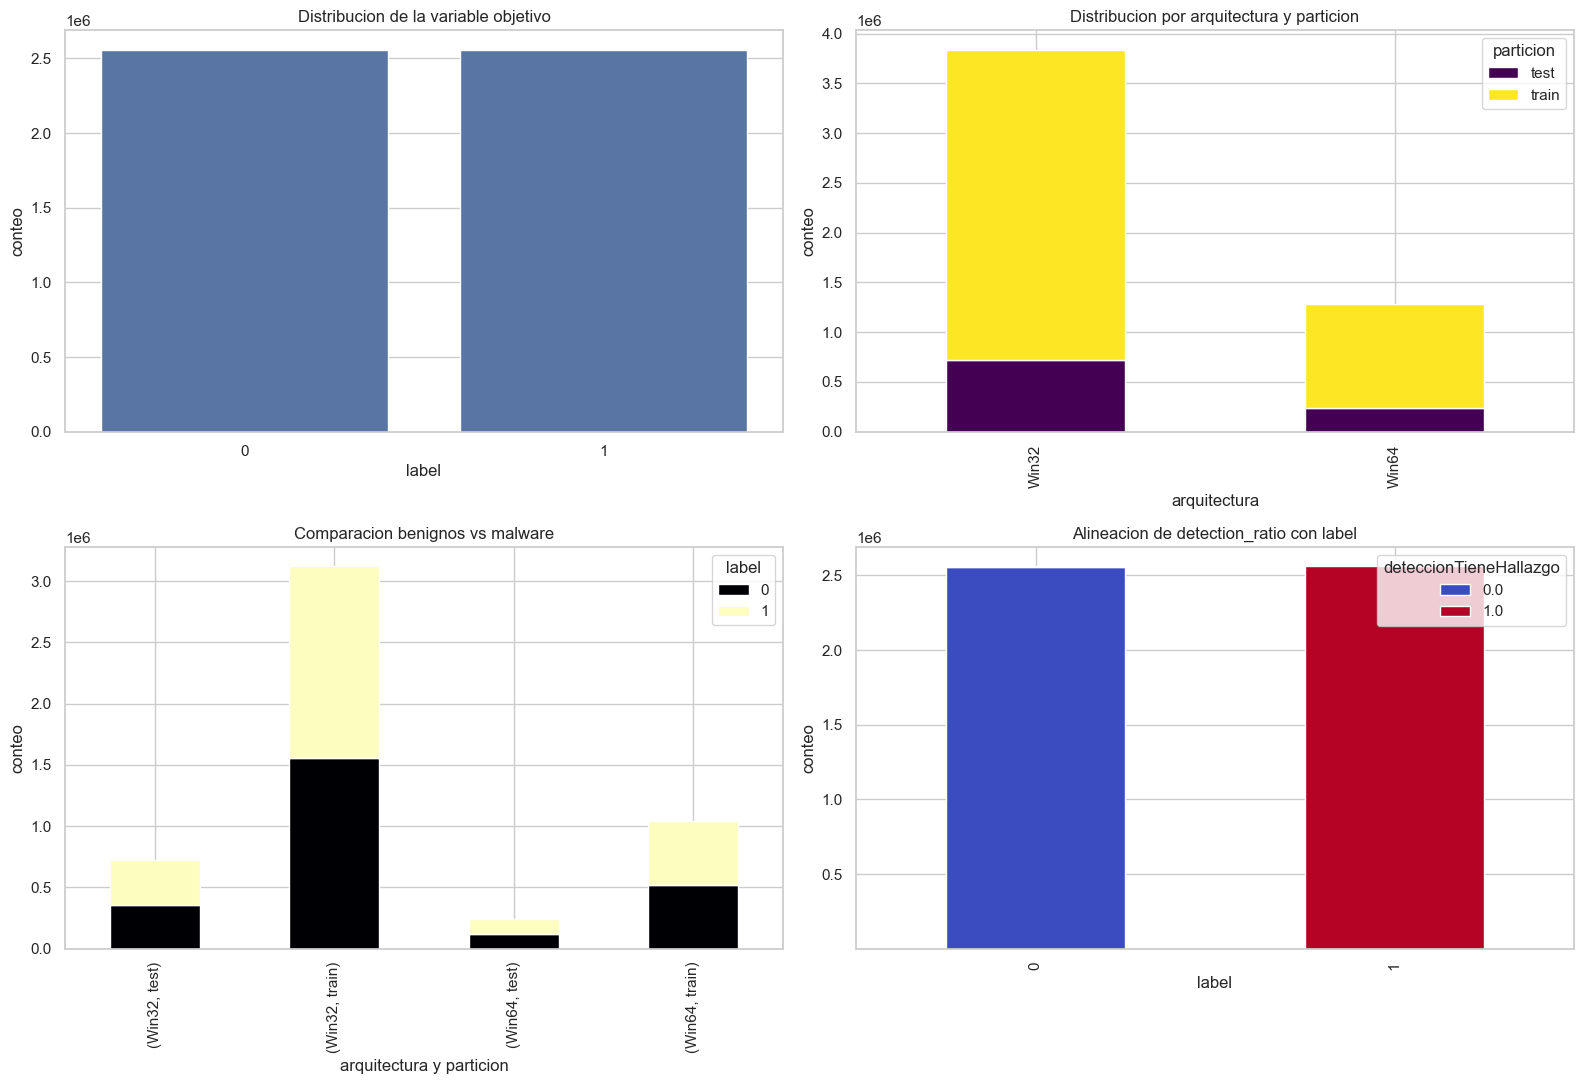

In [18]:
# Genera graficas resumen para visualizar la distribucion global de labels, particiones y deteccion y su alineacion
distribucionLabelDf = metricasEdaBrutas["distribucionLabel"]
distribucionArquitecturaParticionDf = metricasEdaBrutas["distribucionArquitecturaParticion"]
distribucionArquitecturaParticionLabelDf = metricasEdaBrutas["distribucionArquitecturaParticionLabel"]
alineacionDeteccionLabelDf = metricasEdaBrutas["alineacionDeteccionLabel"]

figura, ejes = plt.subplots(2, 2, figsize=(16, 11))

sns.barplot(data=distribucionLabelDf, x="label", y="conteo", ax=ejes[0, 0], color="#4C72B0")
ejes[0, 0].set_title("Distribucion de la variable objetivo")
ejes[0, 0].set_xlabel("label")
ejes[0, 0].set_ylabel("conteo")

tablaPivotArquitecturaParticion = distribucionArquitecturaParticionDf.pivot(
    index="arquitectura",
    columns="particion",
    values="conteo",
).fillna(0)
tablaPivotArquitecturaParticion.plot(kind="bar", stacked=True, ax=ejes[0, 1], colormap="viridis")
ejes[0, 1].set_title("Distribucion por arquitectura y particion")
ejes[0, 1].set_xlabel("arquitectura")
ejes[0, 1].set_ylabel("conteo")
ejes[0, 1].legend(title="particion")

tablaPivotArquitecturaParticionLabel = distribucionArquitecturaParticionLabelDf.pivot_table(
    index=["arquitectura", "particion"],
    columns="label",
    values="conteo",
    fill_value=0,
)
tablaPivotArquitecturaParticionLabel.plot(kind="bar", stacked=True, ax=ejes[1, 0], colormap="magma")
ejes[1, 0].set_title("Comparacion benignos vs malware")
ejes[1, 0].set_xlabel("arquitectura y particion")
ejes[1, 0].set_ylabel("conteo")

if not alineacionDeteccionLabelDf.empty:
    tablaPivotDeteccion = alineacionDeteccionLabelDf.pivot(
        index="label",
        columns="deteccionTieneHallazgo",
        values="conteo",
    ).fillna(0)
    tablaPivotDeteccion.plot(kind="bar", stacked=True, ax=ejes[1, 1], colormap="coolwarm")
    ejes[1, 1].set_title("Alineacion de detection_ratio con label")
    ejes[1, 1].set_xlabel("label")
    ejes[1, 1].set_ylabel("conteo")
    ejes[1, 1].legend(title="deteccionTieneHallazgo")
else:
    ejes[1, 1].set_title("Alineacion de detection_ratio con label")
    ejes[1, 1].text(0.5, 0.5, "sin datos", ha="center", va="center")
    ejes[1, 1].axis("off")

plt.tight_layout()
plt.show()


### Interpretacion 
Las graficas muestran que la variable objetivo esta practicamente balanceada entre benignos y malware, lo cual es positivo para las siguientes fases del modelado. Tambien se observa que la mayor parte de los registros se concentra en Win32, especialmente en train, mientras que Win64 tiene una presencia menor. Al separar por arquitectura y particion, se mantiene una distribucion bastante pareja entre clases, sin un desbalance fuerte. Por ultimo, la alineacion entre detection_ratio y label se ve muy consistente, ya que los registros con label = 0 se asocian generalmente con ausencia de hallazgos y los de label = 1 con presencia de hallazgos.

In [19]:
# Muestra los valores mas frecuentes de familias, comportamientos y categorias clave del dataset
print("top familias")
print(metricasEdaBrutas["topFamily"].head(15).to_string(index=False))
print()
print("top behavior")
print(metricasEdaBrutas["topBehavior"].head(15).to_string(index=False))
print()
print("top file_property")
print(metricasEdaBrutas["topFileProperty"].head(15).to_string(index=False))
print()
print("top packer")
print(metricasEdaBrutas["topPacker"].head(15).to_string(index=False))
print()
print("top exploit")
print(metricasEdaBrutas["topExploit"].head(15).to_string(index=False))
print()
print("top group")
print(metricasEdaBrutas["topGroup"].head(15).to_string(index=False))


top familias
     family  conteo
     berbew  348916
     expiro  148662
    wacatac  121750
      cosmu  107900
      xmrig   57056
     upatre   50564
      sfone   44350
   glupteba   43324
grandoreiro   41082
  flystudio   36258
    sinowal   34578
      virut   20508
     floxif   19254
 tempedreve   18952
   mimikatz   18490

top behavior
       behavior  conteo
       backdoor  396064
          virus  241414
           worm  150724
     downloader  107926
        spyware   73926
      coinminer   72686
        dropper   46122
         adware   30138
         ransom   27586
passwordstealer   26934
        stealer   24060
         packed   22020
       injector   20026
        selfmod   19938
            pua   18980

top file_property
fileProperty  conteo
          vb   39396
      python   19412
        msil   13372
   codecpack    8998
      autoit    6118
         bat    2700
        hllo    2132
   shellcode    1342
          js     730
  powershell     414
        java     29

### Interpretacion 

Los resultados muestran que el dataset contiene una variedad de familias y comportamientos, pero con algunas categorias claramente dominantes. En familias resaltan berbew, expiro, wacatac y cosmu, mientras que en comportamiento predominan backdoor, virus, worm y downloader, lo que dice que hay una fuerte presencia de amenazas orientadas a acceso remoto, propagacion y descarga de cargas maliciosas. En file_property destacan vb, python y msil, lo que indica diversidad en tecnologias o formatos asociados al malware. En packer, sobresalen upx, vmprotect y themida, lo que refuerza la relevancia de tecnicas de empaquetado y ofuscacion. Por su parte, exploit y group tienen mucha menor frecuencia, por lo que pueden ser utiles como señales complementarias, pero no como variables centrales debido a su baja cobertura.

## Analisis de variables numericas


In [ ]:
# Resume las variables numericas y calcula outliers para entender su comportamiento general
columnasNumericasRapidas = [
    columna
    for columna in muestraAnaliticaRapidaDf.columns
    if pd.api.types.is_numeric_dtype(muestraAnaliticaRapidaDf[columna])
]

columnasNumericasRapidas = [
    columna
    for columna in columnasNumericasRapidas
    if columna not in {"label", "indiceChunk"}
]

estadisticosNumericosDf = (
    muestraAnaliticaRapidaDf[columnasNumericasRapidas]
    .replace([np.inf, -np.inf], np.nan)
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)
estadisticosNumericosDf.to_csv(rutaMetricas / "estadisticosNumericosRapidos.csv", index=False)

def calcularOutliersIqr(dfNumerico):
    registros = []
    for columna in dfNumerico.columns:
        serie = dfNumerico[columna].dropna()
        if serie.empty:
            continue
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limiteInferior = q1 - 1.5 * iqr
        limiteSuperior = q3 + 1.5 * iqr
        cantidadOutliers = int(((serie < limiteInferior) | (serie > limiteSuperior)).sum())
        registros.append(
            {
                "variable": columna,
                "outliersIqr": cantidadOutliers,
                "proporcionOutliers": cantidadOutliers / len(serie),
            }
        )
    return pd.DataFrame(registros).sort_values("proporcionOutliers", ascending=False)


resumenOutliersDf = calcularOutliersIqr(
    muestraAnaliticaRapidaDf[columnasNumericasRapidas].replace([np.inf, -np.inf], np.nan)
)
resumenOutliersDf.to_csv(rutaMetricas / "resumenOutliersRapidos.csv", index=False)
estadisticosNumericosDf.head(20)


,variable,count,mean,std,min,5%,25%,50%,75%,95%,max
0,first_submission_date,40000.0,1.728306e+09,8.224673e+05,1.726963e+09,1.727032e+09,1.727660e+09,1.728341e+09,1.728949e+09,1.729709e+09,1.729987e+09
1,last_analysis_date,40000.0,1.731222e+09,2.047897e+06,1.727397e+09,1.727925e+09,1.729849e+09,1.731112e+09,1.732425e+09,1.734584e+09,1.747043e+09
2,family_confidence,17492.0,6.126271e-01,2.784415e-01,9.600000e-02,1.560000e-01,3.390000e-01,7.480000e-01,8.650000e-01,8.880000e-01,9.090000e-01
3,week_id,40000.0,5.375000e+01,1.299054e+00,5.200000e+01,5.200000e+01,5.300000e+01,5.400000e+01,5.500000e+01,5.600000e+01,5.600000e+01
4,deteccionNumerador,40000.0,2.311492e+01,2.754699e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.800000e+01,6.400000e+01,6.900000e+01
5,deteccionDenominador,40000.0,7.335360e+01,5.435756e-01,6.900000e+01,7.300000e+01,7.300000e+01,7.300000e+01,7.400000e+01,7.400000e+01,7.400000e+01
6,deteccionProporcion,40000.0,3.143221e-01,3.743962e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.945205e-01,8.767123e-01,9.324324e-01
7,deteccionTieneHallazgo,40000.0,4.936500e-01,4.999659e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
8,tamanoGeneral,40000.0,2.003349e+06,7.693334e+06,5.120000e+02,1.331200e+04,4.920600e+04,1.533770e+05,9.195520e+05,7.617768e+06,9.856617e+07
9,entropiaGeneral,40000.0,6.348614e+00,1.314096e+00,1.080431e-03,3.577409e+00,5.915896e+00,6.624861e+00,7.100597e+00,7.975812e+00,7.999994e+00


### Interpretacion 
Estos resultados muestran que las variables numericas tienen escalas muy distintas y, en varios casos, una dispersion alta. Por ejemplo, tamanoGeneral, numStrings, printablesStrings y tamanoOverlay presentan valores muy amplios entre registros, lo que sugiere presencia de archivos muy heterogeneos y posibles valores extremos. En cambio, variables como deteccionDenominador y esPeGeneral son mucho mas estables, con poca variacion. Tambien se observa que family_confidence solo esta disponible en una parte de la muestra, mientras que el resto de variables resumidas tiene cobertura casi completa. En general, esta salida confirma que varias variables numericas pueden ser informativas, pero algunas probablemente requeriran escalado, transformaciones o tratamiento de outliers antes del modelado.

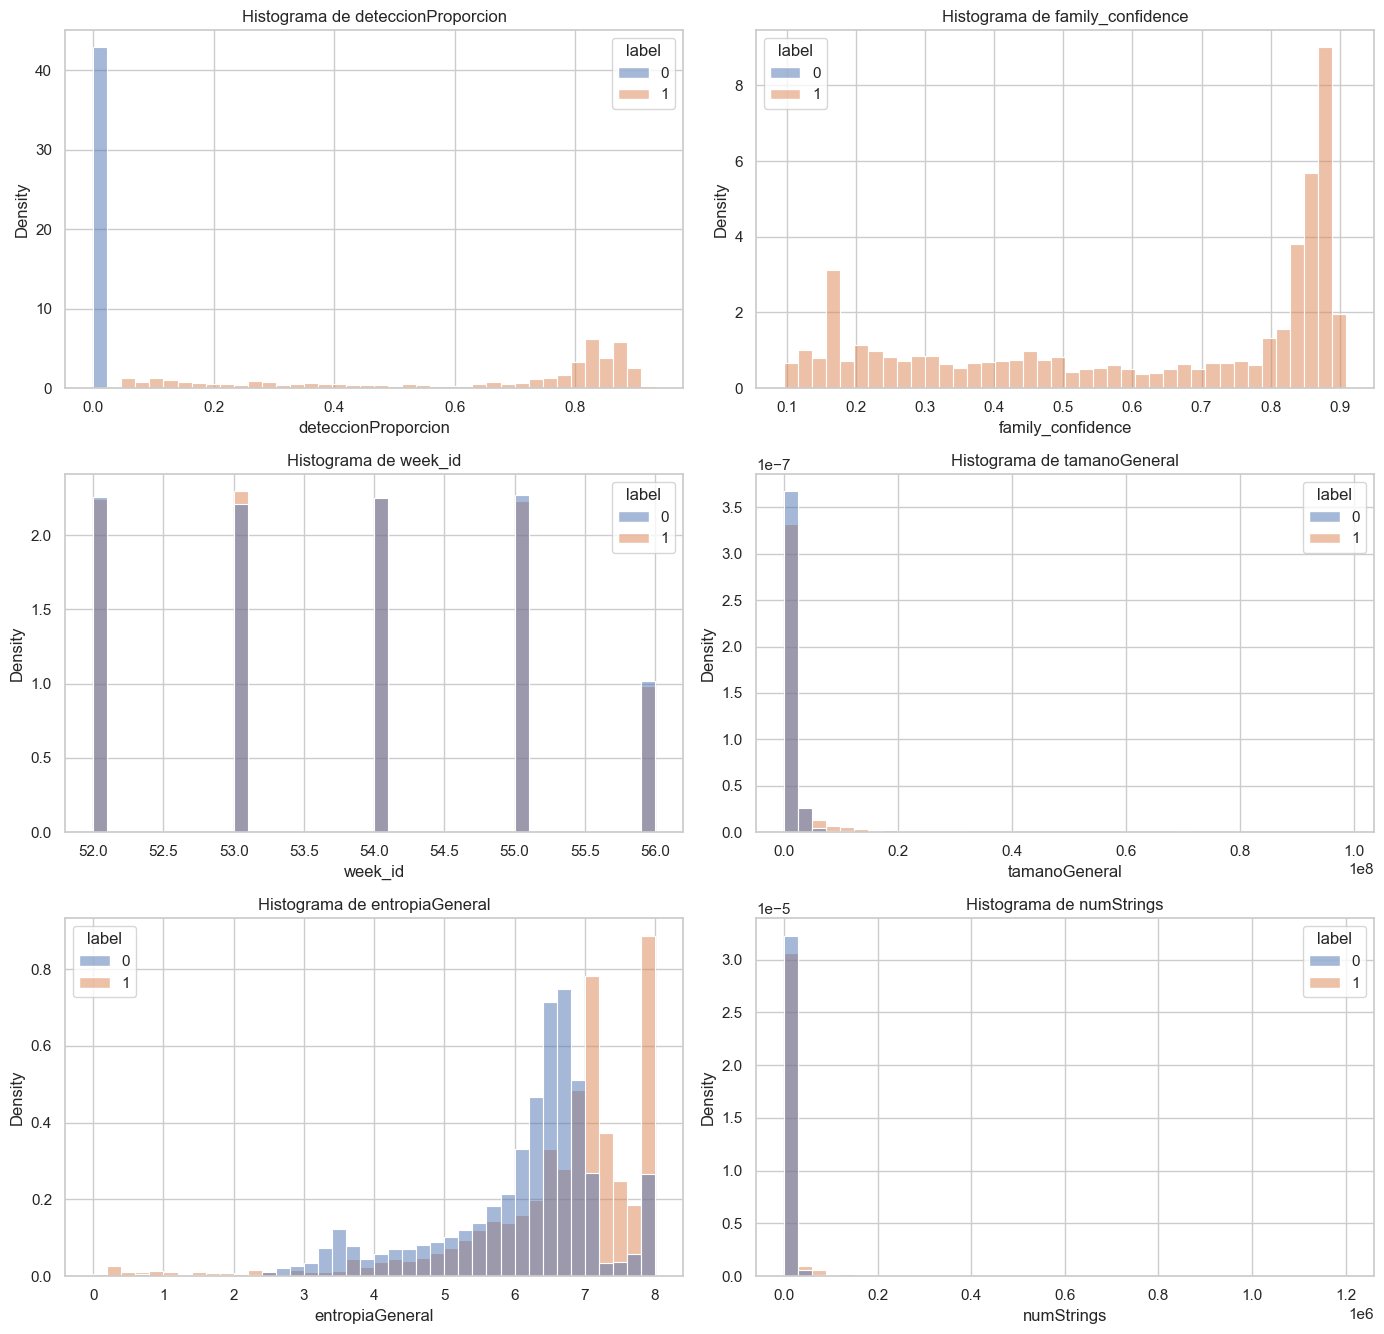

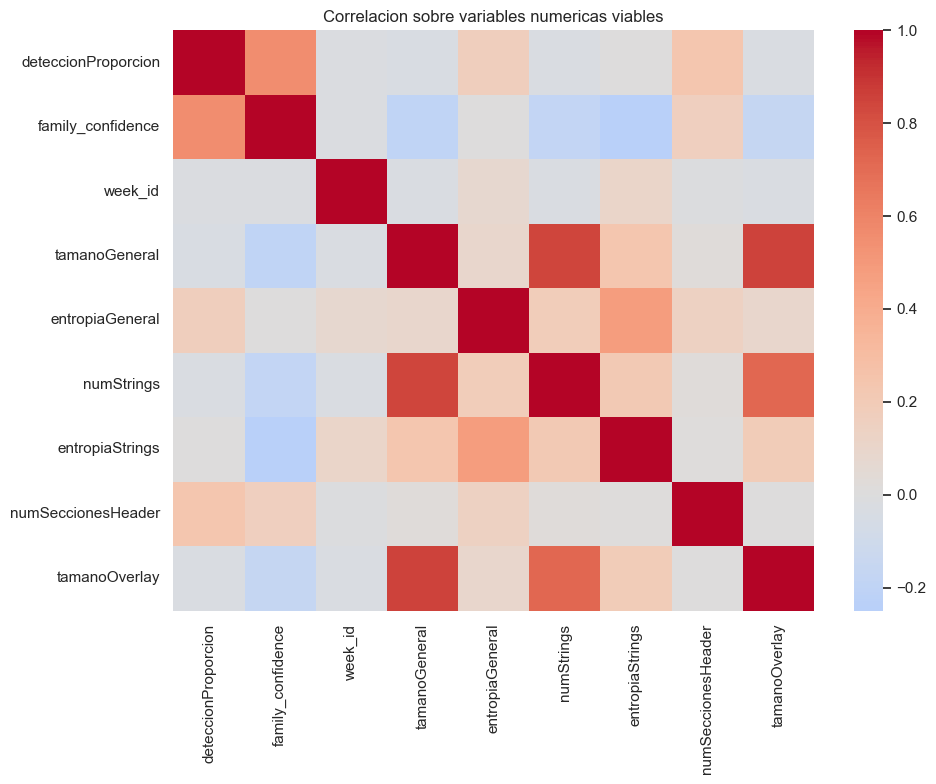

In [ ]:
# Genera histogramas y una matriz de correlacion para revisar la forma y relacion de variables numerica
columnasGraficas = [
    columna
    for columna in [
        "deteccionProporcion",
        "family_confidence",
        "week_id",
        "tamanoGeneral",
        "entropiaGeneral",
        "numStrings",
        "entropiaStrings",
        "numSeccionesHeader",
        "tamanoOverlay",
    ]
    if columna in muestraAnaliticaRapidaDf.columns
]

if columnasGraficas:
    figura, ejes = plt.subplots(
        nrows=min(3, len(columnasGraficas)),
        ncols=2,
        figsize=(14, min(3, len(columnasGraficas)) * 4.5),
    )
    ejes = np.atleast_2d(ejes)

    for indice, columna in enumerate(columnasGraficas[: len(ejes.flatten())]):
        eje = ejes.flatten()[indice]
        sns.histplot(
            data=muestraAnaliticaRapidaDf,
            x=columna,
            hue="label" if "label" in muestraAnaliticaRapidaDf.columns else None,
            bins=40,
            stat="density",
            common_norm=False,
            ax=eje,
        )
        eje.set_title(f"Histograma de {columna}")

    for eje in ejes.flatten()[len(columnasGraficas):]:
        eje.axis("off")

    plt.tight_layout()
    plt.show()

# se hace la seleccion de columnas nums
columnasCorrelacion = [
    columna
    for columna in columnasGraficas
    if muestraAnaliticaRapidaDf[columna].notna().sum() > 10
][:maximoColumnasCorrelacion]

if len(columnasCorrelacion) >= 2:
    matrizCorrelacionDf = muestraAnaliticaRapidaDf[columnasCorrelacion].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrizCorrelacionDf, cmap="coolwarm", center=0)
    plt.title("Correlacion sobre variables numericas viables")
    plt.tight_layout()
    plt.show()


### Interpretacion

- En deteccionProporcion se observa la separacion mas clara de todas, los benignos se concentran casi por completo en valores cercanos a cero, mientras que los maliciosos se acumulan en valores altos, especialmente arriba de 0.7. Esto sugiere que esta variable tiene una relacion muy fuerte con la clase y probablemente sera una de las mas discriminantes del conjunto.

- En family_confidence los valores se concentran sobre todo en rangos altos, cercanos a 0.8 y 0.9, lo que indica que cuando esta variable existe suele venir con confianza relativamente elevada. Sin embargo, no esta presente en todos los registros, asi que puede aportar informacion util pero no debe considerarse una variable universal.

- En week_id no se observa una diferencia fuerte entre clases. La distribucion esta repartida entre las semanas disponibles y parece mas una variable de ubicacion temporal del registro que una caracteristica directamente discriminante por si sola.

- En tamanoGeneral la mayoria de archivos se concentra en tamanos bajos o moderados, pero existe una cola larga de archivos mucho mas grandes. La superposicion entre clases es alta, por lo que el tamaño por si solo no parece separar claramente benignos y malware, aunque si puede complementar a otras variables.

- En entropiaGeneral si aparece una señal mas interesante. Los maliciosos tienden a concentrarse en niveles de entropia mas altos, mientras que los benignos muestran una distribucion algo mas extendida hacia valores menores. Esto es coherente con la idea de que archivos empaquetados u ofuscados suelen presentar mayor entropia.

- En numStrings la distribucion esta muy sesgada hacia valores bajos y medianos, pero con algunos casos extremos muy altos. Hay bastante superposicion entre clases, asi que no parece ser una variable decisiva por si sola, aunque puede seguir siendo util al combinarse con tamano, entropia y otras caracteristicas.

- En la matriz de correlacion tambien aparecen relaciones relevantes. tamanoGeneral, numStrings y tamanoOverlay muestran correlaciones positivas relativamente altas entre si, lo cual tiene sentido porque archivos mas grandes tienden a contener mas cadenas y overlays mas extensos. Tambien se observa una relacion positiva entre entropiaGeneral y entropiaStrings, lo que dice que hay cierta coherencia entre la complejidad general del archivo y la de sus cadenas. Por otro lado, family_confidence presenta correlaciones bajas o incluso negativas con varias variables de tamaño, lo que indica que mide un aspecto distinto del archivo. 

## Analisis de variables complejas

Primero se identifican patrones frecuentes, luego se construyen vocabularios controlados y finalmente se resumen las estructuras complejas en estadisticos o indicadores compactos.


In [ ]:
# Actualiza un contador con valores validos para construir vocabularios frecuentes
def actualizarContadorTop(contadorBase, valores):
    contadorBase.update([str(valor) for valor in valores if str(valor).strip() not in {"", "None", "nan"}])

# Recorre todos los chunks y construye vocabularios con las categorias mas frecuentes del dataset
def construirVocabulariosFrecuentes(tablaChunks):
    if rutaVocabulariosJson.exists() and not reprocesarVocabularios:
        contenidoVocabularios = cargarJsonSeguro(rutaVocabulariosJson, {})
        return contenidoVocabularios.get("vocabularios", {})

    contadores = {
        "behavior": Counter(),
        "fileProperty": Counter(),
        "packer": Counter(),
        "exploit": Counter(),
        "group": Counter(),
        "sectionName": Counter(),
        "sectionProp": Counter(),
        "importsDll": Counter(),
        "importsApi": Counter(),
        "coffCharacteristic": Counter(),
        "dllCharacteristic": Counter(),
        "machine": Counter(),
        "subsystem": Counter(),
        "capsNamespace": Counter(),
        "capsCapability": Counter(),
        "ttpsTechnique": Counter(),
        "mbcBehavior": Counter(),
        "mbcObjective": Counter(),
        "stringCountClave": Counter(),
    }

    for filaChunk in tablaChunks.to_dict("records"):
        columnasLectura = [
            "behavior",
            "file_property",
            "packer",
            "exploit",
            "group",
            "section",
            "imports",
            "header",
            "caps",
            "ttps",
            "mbc",
            "strings",
        ]
        dfChunk = leerParquetSeguro(filaChunk["rutaChunk"], columnasDeseadas=columnasLectura)
        for valor in dfChunk.get("behavior", pd.Series(dtype=object)):
            actualizarContadorTop(contadores["behavior"], deserializarEstructura(valor, list))
        for valor in dfChunk.get("file_property", pd.Series(dtype=object)):
            actualizarContadorTop(contadores["fileProperty"], deserializarEstructura(valor, list))
        for valor in dfChunk.get("packer", pd.Series(dtype=object)):
            actualizarContadorTop(contadores["packer"], deserializarEstructura(valor, list))
        for valor in dfChunk.get("exploit", pd.Series(dtype=object)):
            actualizarContadorTop(contadores["exploit"], deserializarEstructura(valor, list))
        for valor in dfChunk.get("group", pd.Series(dtype=object)):
            actualizarContadorTop(contadores["group"], deserializarEstructura(valor, list))
        for valor in dfChunk.get("section", pd.Series(dtype=object)):
            seccionDict = deserializarEstructura(valor, dict)
            listaSecciones = seccionDict.get("sections", [])
            for seccionActual in listaSecciones:
                if isinstance(seccionActual, dict):
                    if "name" in seccionActual:
                        contadores["sectionName"].update([str(seccionActual["name"])])
                    actualizarContadorTop(contadores["sectionProp"], seccionActual.get("props", []))
        for valor in dfChunk.get("imports", pd.Series(dtype=object)):
            importsDict = deserializarEstructura(valor, dict)
            contadores["importsDll"].update(importsDict.keys())
            for listaFunciones in importsDict.values():
                if isinstance(listaFunciones, list):
                    actualizarContadorTop(contadores["importsApi"], listaFunciones)
        for valor in dfChunk.get("header", pd.Series(dtype=object)):
            headerDict = deserializarEstructura(valor, dict)
            coffDict = headerDict.get("coff", {})
            optionalDict = headerDict.get("optional", {})
            actualizarContadorTop(contadores["coffCharacteristic"], coffDict.get("characteristics", []))
            actualizarContadorTop(contadores["dllCharacteristic"], optionalDict.get("dll_characteristics", []))
            if "machine" in coffDict:
                contadores["machine"].update([str(coffDict["machine"])])
            if "subsystem" in optionalDict:
                contadores["subsystem"].update([str(optionalDict["subsystem"])])
        for valor in dfChunk.get("caps", pd.Series(dtype=object)):
            capsLista = deserializarEstructura(valor, list)
            for item in capsLista:
                if isinstance(item, dict):
                    if "Namespace" in item:
                        contadores["capsNamespace"].update([str(item["Namespace"])])
                    if "Capability" in item:
                        contadores["capsCapability"].update([str(item["Capability"])])
        for valor in dfChunk.get("ttps", pd.Series(dtype=object)):
            ttpsLista = deserializarEstructura(valor, list)
            for item in ttpsLista:
                if isinstance(item, dict) and "Technique" in item:
                    contadores["ttpsTechnique"].update([str(item["Technique"])])
        for valor in dfChunk.get("mbc", pd.Series(dtype=object)):
            mbcLista = deserializarEstructura(valor, list)
            for item in mbcLista:
                if isinstance(item, dict):
                    if "Behavior" in item:
                        contadores["mbcBehavior"].update([str(item["Behavior"])])
                    if "Objective" in item:
                        contadores["mbcObjective"].update([str(item["Objective"])])
        for valor in dfChunk.get("strings", pd.Series(dtype=object)):
            stringsDict = deserializarEstructura(valor, dict)
            stringCounts = stringsDict.get("string_counts", {})
            if isinstance(stringCounts, dict):
                contadores["stringCountClave"].update(stringCounts.keys())
        del dfChunk
        gc.collect()
    vocabularios = {
        nombre: [valor for valor, _ in contador.most_common(topCategoriasFrecuentes)]
        for nombre, contador in contadores.items()
    }
    guardarJsonSeguro(
        rutaVocabulariosJson,
        {
            "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
            "topCategoriasFrecuentes": topCategoriasFrecuentes,
            "vocabularios": vocabularios,
        },
    )
    for nombre, contador in contadores.items():
        tablaFrecuencias = pd.DataFrame(
            [{"valor": valor, "conteo": conteo} for valor, conteo in contador.most_common(200)]
        )
        tablaFrecuencias.to_csv(rutaMetricas / f"frecuencias_{nombre}.csv", index=False)

    return vocabularios


vocabulariosFrecuentes = construirVocabulariosFrecuentes(tablaChunksBrutos)
pd.DataFrame(
    [
        {"vocabulario": nombre, "tamano": len(valores), "valores": ", ".join(valores[:8])}
        for nombre, valores in vocabulariosFrecuentes.items()
    ]
).sort_values("vocabulario")


,vocabulario,tamano,valores
0,behavior,15,"backdoor, virus, worm, downloader, spyware, co..."
14,capsCapability,15,"Link function at runtime on windows, Encode da..."
13,capsNamespace,15,"linking/runtime-linking, load-code/pe, host-in..."
9,coffCharacteristic,15,"EXECUTABLE_IMAGE, 32BIT_MACHINE, LINE_NUMS_STR..."
10,dllCharacteristic,11,"NX_COMPAT, DYNAMIC_BASE, TERMINAL_SERVER_AWARE..."
3,exploit,15,"cve_2017_0147, ms17_010, cve_2020_0601, cve_20..."
1,fileProperty,15,"vb, python, msil, codecpack, autoit, bat, hllo..."
4,group,15,"gamaredon, equationgroup, turla, molerats, apt..."
8,importsApi,15,"GetProcAddress, GetCurrentThreadId, CloseHandl..."
7,importsDll,15,"KERNEL32.dll, USER32.dll, ADVAPI32.dll, ole32...."


### Interpretacion

Este resultado muestra que ya se construyeron los vocabularios frecuentes del dataset, es decir, los conjuntos de valores mas repetidos dentro de varias columnas categoricas y estructuras complejas. Esto permite identificar cuales son las categorias mas representativas del conjunto y luego usarlas para una expansion controlada de variables, evitando crear miles de columnas raras o poco utiles. Por ejemplo, en behavior predominan categorias como backdoor, virus y worm; en packer destacan upx, vmprotect y themida; en sectionName aparecen secciones PE muy comunes como .rsrc, .text y .data; y en importsDll e importsApi se observan librerias y funciones de Windows muy frecuentes. En conjunto, estos vocabularios sirven como base para transformar informacion categorica compleja en variables mas utiles para el modelado.

In [ ]:
# funcion nombres y resume estructuras complejas para generar caracteristicas mas estables
def normalizarNombreCaracteristica(texto):
    texto = str(texto).lower()
    reemplazos = {
        " ": "_",
        "-": "_",
        ".": "_",
        "/": "_",
        "\\": "_",
        "[": "_",
        "]": "_",
        "(": "_",
        ")": "_",
        ":": "_",
        ",": "_",
        ";": "_",
        "'": "",
        "&": "and",
        "%": "pct",
        "+": "plus",
        "#": "num",
        "*": "x",
    }
    for origen, destino in reemplazos.items():
        texto = texto.replace(origen, destino)
    while "__" in texto:
        texto = texto.replace("__", "_")
    return texto.strip("_")[:80] or "vacio"

# Resume listas numericas con estadisticos utiles para el modelado
def resumirVectorNumerico(vector, prefijo):
    columnasBase = {
        f"{prefijo}Conteo": 0,
        f"{prefijo}Suma": np.nan,
        f"{prefijo}Media": np.nan,
        f"{prefijo}Desviacion": np.nan,
        f"{prefijo}Min": np.nan,
        f"{prefijo}Max": np.nan,
        f"{prefijo}P25": np.nan,
        f"{prefijo}P50": np.nan,
        f"{prefijo}P75": np.nan,
        f"{prefijo}Energia": np.nan,
        f"{prefijo}Sparsity": np.nan,
    }

    if not isinstance(vector, list) or len(vector) == 0:
        return columnasBase
    try:
        arreglo = np.asarray(vector, dtype=float)
    except Exception:
        return columnasBase
    if arreglo.size == 0:
        return columnasBase

    columnasBase.update(
        {
            f"{prefijo}Conteo": int(arreglo.size),
            f"{prefijo}Suma": float(np.sum(arreglo)),
            f"{prefijo}Media": float(np.mean(arreglo)),
            f"{prefijo}Desviacion": float(np.std(arreglo)),
            f"{prefijo}Min": float(np.min(arreglo)),
            f"{prefijo}Max": float(np.max(arreglo)),
            f"{prefijo}P25": float(np.percentile(arreglo, 25)),
            f"{prefijo}P50": float(np.percentile(arreglo, 50)),
            f"{prefijo}P75": float(np.percentile(arreglo, 75)),
            f"{prefijo}Energia": float(np.square(arreglo).sum()),
            f"{prefijo}Sparsity": float(np.mean(arreglo == 0)),
        }
    )
    return columnasBase

# Resume diccionarios de conteos en variables numericas compactas
def resumirConteoDiccionario(diccionarioConteos, prefijo):
    salida = {
        f"{prefijo}Claves": 0,
        f"{prefijo}Suma": np.nan,
        f"{prefijo}Max": np.nan,
        f"{prefijo}Media": np.nan,
    }

    if not isinstance(diccionarioConteos, dict) or len(diccionarioConteos) == 0:
        return salida
    try:
        valores = np.asarray(list(diccionarioConteos.values()), dtype=float)
    except Exception:
        return salida
    salida.update(
        {
            f"{prefijo}Claves": int(len(diccionarioConteos)),
            f"{prefijo}Suma": float(np.sum(valores)),
            f"{prefijo}Max": float(np.max(valores)),
            f"{prefijo}Media": float(np.mean(valores)),
        }
    )
    return salida

# Convierte listas categoricas en indicadores basados en vocabularios frecuentes
def extraerIndicadoresCategorias(listaValores, prefijo, categoriasTop):
    listaLimpia = [str(valor) for valor in listaValores if str(valor).strip() not in {"", "None", "nan"}]
    salida = {
        f"{prefijo}Conteo": int(len(listaLimpia)),
        f"{prefijo}Distintos": int(len(set(listaLimpia))),
    }
    contadorLocal = Counter(listaLimpia)
    for categoria in categoriasTop:
        nombreColumna = f"{prefijo}_{normalizarNombreCaracteristica(categoria)}"
        salida[nombreColumna] = int(contadorLocal.get(str(categoria), 0))
    return salida

# Extrae caracteristicas resumidas del bloque strings
def extraerCaracteristicasStrings(stringsValor, vocabularios):
    stringsDict = deserializarEstructura(stringsValor, dict)
    printabledist = stringsDict.get("printabledist", [])
    stringCounts = stringsDict.get("string_counts", {})

    salida = {
        "stringsNumStrings": stringsDict.get("numstrings", np.nan),
        "stringsLongitudPromedio": stringsDict.get("avlength", np.nan),
        "stringsPrintables": stringsDict.get("printables", np.nan),
        "stringsEntropia": stringsDict.get("entropy", np.nan),
    }
    salida.update(resumirVectorNumerico(printabledist, "stringsPrintableDist"))
    salida.update(resumirConteoDiccionario(stringCounts, "stringsConteos"))

    for claveTop in vocabularios.get("stringCountClave", []):
        nombreColumna = f"stringsClave_{normalizarNombreCaracteristica(claveTop)}"
        salida[nombreColumna] = float(stringCounts.get(claveTop, 0)) if isinstance(stringCounts, dict) else 0.0
    return salida

# Extrae caracteristicas resumidas del bloque general
def extraerCaracteristicasGeneral(generalValor):
    generalDict = deserializarEstructura(generalValor, dict)
    startBytes = generalDict.get("start_bytes", [])
    salida = {
        "generalTamano": generalDict.get("size", np.nan),
        "generalEntropia": generalDict.get("entropy", np.nan),
        "generalEsPe": generalDict.get("is_pe", np.nan),
    }
    for indice, valor in enumerate(startBytes[:4]):
        salida[f"generalStartByte{indice}"] = valor
    return salida


In [ ]:
# Extrae caracteristicas numericas y banderas utiles del bloque header
def extraerCaracteristicasHeader(headerValor, vocabularios):
    headerDict = deserializarEstructura(headerValor, dict)
    coffDict = headerDict.get("coff", {})
    optionalDict = headerDict.get("optional", {})
    dosDict = headerDict.get("dos", {})

    salida = {
        "headerCoffTimestamp": coffDict.get("timestamp", np.nan),
        "headerCoffNumeroSecciones": coffDict.get("number_of_sections", np.nan),
        "headerCoffNumeroSimbolos": coffDict.get("number_of_symbols", np.nan),
        "headerCoffTamanoOptionalHeader": coffDict.get("sizeof_optional_header", np.nan),
        "headerOptionalMagic": optionalDict.get("magic", np.nan),
        "headerOptionalMajorLinkerVersion": optionalDict.get("major_linker_version", np.nan),
        "headerOptionalMinorLinkerVersion": optionalDict.get("minor_linker_version", np.nan),
        "headerOptionalSizeofCode": optionalDict.get("sizeof_code", np.nan),
        "headerOptionalSizeofHeaders": optionalDict.get("sizeof_headers", np.nan),
        "headerOptionalSizeofImage": optionalDict.get("sizeof_image", np.nan),
        "headerOptionalSizeofInitializedData": optionalDict.get("sizeof_initialized_data", np.nan),
        "headerOptionalSizeofUninitializedData": optionalDict.get("sizeof_uninitialized_data", np.nan),
        "headerOptionalAddressOfEntrypoint": optionalDict.get("address_of_entrypoint", np.nan),
        "headerOptionalImageBase": optionalDict.get("image_base", np.nan),
        "headerOptionalSectionAlignment": optionalDict.get("section_alignment", np.nan),
        "headerOptionalChecksum": optionalDict.get("checksum", np.nan),
        "headerOptionalNumberOfRvasAndSizes": optionalDict.get("number_of_rvas_and_sizes", np.nan),
        "headerDosELfanew": dosDict.get("e_lfanew", np.nan),
        "headerDosECp": dosDict.get("e_cp", np.nan),
        "headerDosECblp": dosDict.get("e_cblp", np.nan),
        "headerDosECparhdr": dosDict.get("e_cparhdr", np.nan),
        "headerCoffCharacteristicsConteo": len(coffDict.get("characteristics", [])) if isinstance(coffDict, dict) else 0,
        "headerOptionalDllCharacteristicsConteo": len(optionalDict.get("dll_characteristics", [])) if isinstance(optionalDict, dict) else 0,
    }

    for valorTop in vocabularios.get("machine", []):
        salida[f"headerMachine_{normalizarNombreCaracteristica(valorTop)}"] = int(coffDict.get("machine") == valorTop)
    for valorTop in vocabularios.get("subsystem", []):
        salida[f"headerSubsystem_{normalizarNombreCaracteristica(valorTop)}"] = int(optionalDict.get("subsystem") == valorTop)
    for valorTop in vocabularios.get("coffCharacteristic", []):
        salida[f"headerCoffChar_{normalizarNombreCaracteristica(valorTop)}"] = int(
            valorTop in coffDict.get("characteristics", [])
        )
    for valorTop in vocabularios.get("dllCharacteristic", []):
        salida[f"headerDllChar_{normalizarNombreCaracteristica(valorTop)}"] = int(
            valorTop in optionalDict.get("dll_characteristics", [])
        )
    return salida

# funcion que extrae caracteristicas resumidas del bloque section y de las secciones PE mas frecuentes
def extraerCaracteristicasSection(sectionValor, vocabularios):
    sectionDict = deserializarEstructura(sectionValor, dict)
    secciones = sectionDict.get("sections", [])
    overlayDict = sectionDict.get("overlay", {})
    nombresSeccion = []
    propsSeccion = []
    entropias = []
    tamanos = []
    vsizes = []
    for seccionActual in secciones:
        if not isinstance(seccionActual, dict):
            continue
        nombresSeccion.append(str(seccionActual.get("name", "")))
        propsSeccion.extend([str(prop) for prop in seccionActual.get("props", [])])
        if seccionActual.get("entropy") is not None:
            entropias.append(seccionActual.get("entropy"))
        if seccionActual.get("size") is not None:
            tamanos.append(seccionActual.get("size"))
        if seccionActual.get("vsize") is not None:
            vsizes.append(seccionActual.get("vsize"))
    salida = {
        "sectionNumeroSecciones": int(len(secciones)),
        "sectionEntropiaMedia": float(np.mean(entropias)) if entropias else np.nan,
        "sectionEntropiaMax": float(np.max(entropias)) if entropias else np.nan,
        "sectionEntropiaStd": float(np.std(entropias)) if entropias else np.nan,
        "sectionTamanoTotal": float(np.sum(tamanos)) if tamanos else np.nan,
        "sectionVsizeTotal": float(np.sum(vsizes)) if vsizes else np.nan,
        "sectionOverlayTamano": overlayDict.get("size", np.nan),
        "sectionOverlayRatio": overlayDict.get("size_ratio", np.nan),
        "sectionOverlayEntropia": overlayDict.get("entropy", np.nan),
        "sectionPropsConteo": int(len(propsSeccion)),
        "sectionPropsDistintos": int(len(set(propsSeccion))),
    }

    contadorNombres = Counter(nombresSeccion)
    contadorProps = Counter(propsSeccion)

    for nombreTop in vocabularios.get("sectionName", []):
        salida[f"sectionNombre_{normalizarNombreCaracteristica(nombreTop)}"] = int(contadorNombres.get(nombreTop, 0))
    for propTop in vocabularios.get("sectionProp", []):
        salida[f"sectionProp_{normalizarNombreCaracteristica(propTop)}"] = int(contadorProps.get(propTop, 0))
    for nombreTop in vocabularios.get("sectionName", []):
        salida[f"sectionEntry_{normalizarNombreCaracteristica(nombreTop)}"] = int(str(sectionDict.get("entry", "")) == nombreTop)
    return salida

In [ ]:
# Extrae caracteristicas resumidas del bloque imports y de las APIs mas frecuentes
def extraerCaracteristicasImports(importsValor, vocabularios):
    importsDict = deserializarEstructura(importsValor, dict)
    totalFunciones = 0
    contadorDll = Counter()
    contadorApi = Counter()
    for dll, funciones in importsDict.items():
        contadorDll.update([str(dll)])
        if isinstance(funciones, list):
            funcionesLimpias = [str(funcion) for funcion in funciones]
            totalFunciones += len(funcionesLimpias)
            contadorApi.update(funcionesLimpias)
    cantidadDlls = int(sum(contadorDll.values()))
    salida = {
        "importsDllsConteo": cantidadDlls,
        "importsFuncionesConteo": int(totalFunciones),
        "importsPromedioFuncionesPorDll": float(totalFunciones / cantidadDlls) if cantidadDlls > 0 else np.nan,
    }
    for dllTop in vocabularios.get("importsDll", []):
        salida[f"importsDll_{normalizarNombreCaracteristica(dllTop)}"] = int(contadorDll.get(dllTop, 0))
    for apiTop in vocabularios.get("importsApi", []):
        salida[f"importsApi_{normalizarNombreCaracteristica(apiTop)}"] = int(contadorApi.get(apiTop, 0))
    return salida

# Extrae variables resumidas relacionadas con firma y certificados del bloque authenticode
def extraerCaracteristicasAuthenticode(authenticodeValor):
    authenticodeDict = deserializarEstructura(authenticodeValor, dict)
    return {
        "authenticodeNumCerts": authenticodeDict.get("num_certs", np.nan),
        "authenticodeSelfSigned": authenticodeDict.get("self_signed", np.nan),
        "authenticodeEmptyProgramName": authenticodeDict.get("empty_program_name", np.nan),
        "authenticodeNoCountersigner": authenticodeDict.get("no_countersigner", np.nan),
        "authenticodeParseError": authenticodeDict.get("parse_error", np.nan),
        "authenticodeChainMaxDepth": authenticodeDict.get("chain_max_depth", np.nan),
        "authenticodeLatestSigningTime": authenticodeDict.get("latest_signing_time", np.nan),
        "authenticodeSigningTimeDiff": authenticodeDict.get("signing_time_diff", np.nan),
    }

# Extrae conteos e indicadores del bloque caps usando los vocabularios frecuentes
def extraerCaracteristicasCaps(capsValor, vocabularios):
    capsLista = deserializarEstructura(capsValor, list)
    namespaces = []
    capacidades = []
    for item in capsLista:
        if isinstance(item, dict):
            if "Namespace" in item:
                namespaces.append(str(item["Namespace"]))
            if "Capability" in item:
                capacidades.append(str(item["Capability"]))
    salida = {
        "capsConteo": int(len(capsLista)),
        "capsNamespacesDistintos": int(len(set(namespaces))),
        "capsCapacidadesDistintas": int(len(set(capacidades))),
    }
    contadorNamespace = Counter(namespaces)
    contadorCapability = Counter(capacidades)
    for valorTop in vocabularios.get("capsNamespace", []):
        salida[f"capsNamespace_{normalizarNombreCaracteristica(valorTop)}"] = int(contadorNamespace.get(valorTop, 0))
    for valorTop in vocabularios.get("capsCapability", []):
        salida[f"capsCapability_{normalizarNombreCaracteristica(valorTop)}"] = int(contadorCapability.get(valorTop, 0))
    return salida

# Extrae conteos e indicadores del bloque ttps a partir de las tecnicas mas frecuentes
def extraerCaracteristicasTtps(ttpsValor, vocabularios):
    ttpsLista = deserializarEstructura(ttpsValor, list)
    tecnicas = []
    for item in ttpsLista:
        if isinstance(item, dict) and "Technique" in item:
            tecnicas.append(str(item["Technique"]))
    salida = {
        "ttpsConteo": int(len(ttpsLista)),
        "ttpsTecnicasDistintas": int(len(set(tecnicas))),
    }
    contadorTecnicas = Counter(tecnicas)
    for valorTop in vocabularios.get("ttpsTechnique", []):
        salida[f"ttpsTechnique_{normalizarNombreCaracteristica(valorTop)}"] = int(contadorTecnicas.get(valorTop, 0))
    return salida

# Extrae conteos e indicadores del bloque mbc separando behaviors y objectives
def extraerCaracteristicasMbc(mbcValor, vocabularios):
    mbcLista = deserializarEstructura(mbcValor, list)
    behaviors = []
    objetivos = []
    for item in mbcLista:
        if isinstance(item, dict):
            if "Behavior" in item:
                behaviors.append(str(item["Behavior"]))
            if "Objective" in item:
                objetivos.append(str(item["Objective"]))
    salida = {
        "mbcConteo": int(len(mbcLista)),
        "mbcBehaviorsDistintos": int(len(set(behaviors))),
        "mbcObjectivesDistintos": int(len(set(objetivos))),
    }
    contadorBehaviors = Counter(behaviors)
    contadorObjectives = Counter(objetivos)
    for valorTop in vocabularios.get("mbcBehavior", []):
        salida[f"mbcBehavior_{normalizarNombreCaracteristica(valorTop)}"] = int(contadorBehaviors.get(valorTop, 0))
    for valorTop in vocabularios.get("mbcObjective", []):
        salida[f"mbcObjective_{normalizarNombreCaracteristica(valorTop)}"] = int(contadorObjectives.get(valorTop, 0))
    return salida

# se reune todas las transformaciones en una sola fila de caracteristicas listas para modelado
def extraerCaracteristicasFila(registroFila, vocabularios):
    salida = {
        "label": registroFila.get("label", np.nan),
        "particion": registroFila.get("particion"),
        "arquitectura": registroFila.get("arquitectura"),
        "archivoOrigen": registroFila.get("archivoOrigen"),
        "identificadorArchivo": registroFila.get("identificadorArchivo"),
        "md5": registroFila.get("md5"),
        "sha1": registroFila.get("sha1"),
        "sha256": registroFila.get("sha256"),
        "tlsh": registroFila.get("tlsh"),
        "family": registroFila.get("family"),
        "familyConfidence": registroFila.get("family_confidence", np.nan),
        "weekId": registroFila.get("week_id", np.nan),
        "firstSubmissionDate": registroFila.get("first_submission_date", np.nan),
        "lastAnalysisDate": registroFila.get("last_analysis_date", np.nan),
    }

    deteccionNumerador, deteccionDenominador, deteccionProporcion, deteccionTieneHallazgo = descomponerDetectionRatio(
        registroFila.get("detection_ratio")
    )
    salida["deteccionNumerador"] = deteccionNumerador
    salida["deteccionDenominador"] = deteccionDenominador
    salida["deteccionProporcion"] = deteccionProporcion
    salida["deteccionTieneHallazgo"] = deteccionTieneHallazgo
    salida.update(resumirVectorNumerico(deserializarEstructura(registroFila.get("histogram"), list), "histograma"))
    salida.update(resumirVectorNumerico(deserializarEstructura(registroFila.get("byteentropy"), list), "byteentropy"))
    salida.update(extraerCaracteristicasStrings(registroFila.get("strings"), vocabularios))
    salida.update(extraerCaracteristicasGeneral(registroFila.get("general")))
    salida.update(extraerCaracteristicasHeader(registroFila.get("header"), vocabularios))
    salida.update(extraerCaracteristicasSection(registroFila.get("section"), vocabularios))
    salida.update(extraerCaracteristicasImports(registroFila.get("imports"), vocabularios))
    salida.update(extraerCaracteristicasAuthenticode(registroFila.get("authenticode")))
    salida.update(extraerCaracteristicasCaps(registroFila.get("caps"), vocabularios))
    salida.update(extraerCaracteristicasTtps(registroFila.get("ttps"), vocabularios))
    salida.update(extraerCaracteristicasMbc(registroFila.get("mbc"), vocabularios))
    salida.update(extraerIndicadoresCategorias(deserializarEstructura(registroFila.get("behavior"), list), "behavior", vocabularios.get("behavior", [])))
    salida.update(extraerIndicadoresCategorias(deserializarEstructura(registroFila.get("file_property"), list), "fileProperty", vocabularios.get("fileProperty", [])))
    salida.update(extraerIndicadoresCategorias(deserializarEstructura(registroFila.get("packer"), list), "packer", vocabularios.get("packer", [])))
    salida.update(extraerIndicadoresCategorias(deserializarEstructura(registroFila.get("exploit"), list), "exploit", vocabularios.get("exploit", [])))
    salida.update(extraerIndicadoresCategorias(deserializarEstructura(registroFila.get("group"), list), "group", vocabularios.get("group", [])))
    return salida

# Aplica la ingenieria de caracteristicas a todas las filas de un chunk
def construirCaracteristicasChunk(dfChunk, vocabularios):
    registrosCaracteristicas = [
        extraerCaracteristicasFila(registroFila, vocabularios)
        for registroFila in dfChunk.to_dict("records")
    ]
    return pd.DataFrame(registrosCaracteristicas)


## Ingenieria de caracteristicas

Las transformaciones elegidas priorizan tres criterios: preservar informacion analitica, evitar explosiones de dimensionalidad y producir un dataset compacto que pueda alimentar el siguiente trabajo. Los hashes e identificadores se conservan solo para trazabilidad, no como predictores principales.


In [ ]:
# se carga y guarda el manifiesto que controla el avance de la ingenieria de caracteristicas
def cargarManifestoCaracteristicas():
    return cargarJsonSeguro(
        rutaManifestoCaracteristicas,
        {"version": 1, "chunks": {}},
    )


def guardarManifestoCaracteristicas(manifestoCaracteristicas):
    guardarJsonSeguro(rutaManifestoCaracteristicas, manifestoCaracteristicas)
    registrosResumen = []
    for identificadorChunk, datosChunk in manifestoCaracteristicas.get("chunks", {}).items():
        filaResumen = {"identificadorChunk": identificadorChunk}
        filaResumen.update(datosChunk)
        registrosResumen.append(filaResumen)
    if registrosResumen:
        pd.DataFrame(registrosResumen).sort_values(
            ["arquitectura", "particion", "archivoOrigen", "indiceChunk"]
        ).to_csv(rutaResumenCaracteristicasCsv, index=False)

# se procesa el chunk generarndo caracteristicas y se actualiza el manifiesto con el resultado 
def procesarChunkACaracteristicas(filaChunk, vocabularios, manifestoCaracteristicas):
    identificadorChunk = f"{filaChunk['identificadorArchivo']}_{int(filaChunk['indiceChunk']):05d}"
    rutaCarpetaSalida = rutaParquetCompacto / filaChunk["identificadorArchivo"]
    rutaCarpetaSalida.mkdir(parents=True, exist_ok=True)
    rutaParquetSalida = rutaCarpetaSalida / f"chunk_{int(filaChunk['indiceChunk']):05d}.parquet"
    rutaMetaSalida = rutaCarpetaSalida / f"chunk_{int(filaChunk['indiceChunk']):05d}.meta.json"

    if reprocesarCaracteristicas and rutaParquetSalida.exists():
        rutaParquetSalida.unlink(missing_ok=True)
        rutaMetaSalida.unlink(missing_ok=True)
    if rutaParquetSalida.exists() and rutaMetaSalida.exists() and not reprocesarCaracteristicas:
        print(f"chunk omitido: {identificadorChunk}")
        return
    try:
        dfChunk = leerParquetSeguro(filaChunk["rutaChunk"])
        dfCaracteristicas = construirCaracteristicasChunk(dfChunk, vocabularios)
        dfCaracteristicas["indiceChunk"] = int(filaChunk["indiceChunk"])
        dfCaracteristicas.to_parquet(rutaParquetSalida, index=False, engine=motorParquet)

        metaSalida = {
            "identificadorArchivo": filaChunk["identificadorArchivo"],
            "archivoOrigen": filaChunk["archivoOrigen"],
            "arquitectura": filaChunk["arquitectura"],
            "particion": filaChunk["particion"],
            "indiceChunk": int(filaChunk["indiceChunk"]),
            "filasValidas": int(len(dfCaracteristicas)),
            "rutaParquetChunk": rutaParquetSalida.as_posix(),
            "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
        }
        guardarJsonSeguro(rutaMetaSalida, metaSalida)
        manifestoCaracteristicas.setdefault("chunks", {})
        manifestoCaracteristicas["chunks"][identificadorChunk] = {
            "identificadorArchivo": filaChunk["identificadorArchivo"],
            "archivoOrigen": filaChunk["archivoOrigen"],
            "arquitectura": filaChunk["arquitectura"],
            "particion": filaChunk["particion"],
            "indiceChunk": int(filaChunk["indiceChunk"]),
            "estado": "completo",
            "filasValidas": int(len(dfCaracteristicas)),
            "rutaEntrada": filaChunk["rutaChunk"].as_posix(),
            "rutaSalida": rutaParquetSalida.as_posix(),
            "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
            "error": None,
        }
        guardarManifestoCaracteristicas(manifestoCaracteristicas)

        del dfChunk
        del dfCaracteristicas
        gc.collect()
        print(f"chunk listo: {identificadorChunk}")
    except Exception as error:
        manifestoCaracteristicas.setdefault("chunks", {})
        manifestoCaracteristicas["chunks"][identificadorChunk] = {
            "identificadorArchivo": filaChunk["identificadorArchivo"],
            "archivoOrigen": filaChunk["archivoOrigen"],
            "arquitectura": filaChunk["arquitectura"],
            "particion": filaChunk["particion"],
            "indiceChunk": int(filaChunk["indiceChunk"]),
            "estado": "error",
            "filasValidas": 0,
            "rutaEntrada": filaChunk["rutaChunk"].as_posix(),
            "rutaSalida": rutaParquetSalida.as_posix(),
            "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
            "error": repr(error),
        }
        guardarManifestoCaracteristicas(manifestoCaracteristicas)
        anexarFilaCsv(
            rutaIncidenciasCaracteristicasCsv,
            {
                "identificadorArchivo": filaChunk["identificadorArchivo"],
                "archivoOrigen": filaChunk["archivoOrigen"],
                "indiceChunk": int(filaChunk["indiceChunk"]),
                "tipoIncidencia": "errorChunkCaracteristicas",
                "detalle": repr(error),
                "fechaRegistro": pd.Timestamp.utcnow().isoformat(),
            },
        )
        print(f"fallo chunk: {identificadorChunk}")

# se ejecuta la ingenieria de caracteristicas sobre todos los chunks brutos y resume los chunks compactos generados
manifestoCaracteristicas = cargarManifestoCaracteristicas()

for filaChunk in tablaChunksBrutos.to_dict("records"):
    procesarChunkACaracteristicas(filaChunk, vocabulariosFrecuentes, manifestoCaracteristicas)
tablaChunksCompactos = listarChunksParquet(rutaParquetCompacto)
print(f"chunks compactos disponibles: {len(tablaChunksCompactos):,}")
tablaChunksCompactos.head(20)


chunk omitido: 97902f7024e48d57_00000
chunk omitido: 97902f7024e48d57_00001
chunk omitido: 97902f7024e48d57_00002
chunk omitido: 97902f7024e48d57_00003
chunk omitido: 97902f7024e48d57_00004
chunk omitido: 97902f7024e48d57_00005
chunk omitido: 97902f7024e48d57_00006
chunk omitido: 97902f7024e48d57_00007
chunk omitido: 97902f7024e48d57_00008
chunk omitido: 97902f7024e48d57_00009
chunk omitido: 97902f7024e48d57_00010
chunk omitido: 97902f7024e48d57_00011
chunk omitido: 97902f7024e48d57_00012
chunk omitido: 97902f7024e48d57_00013
chunk omitido: 97902f7024e48d57_00014
chunk omitido: 97902f7024e48d57_00015
chunk omitido: 97902f7024e48d57_00016
chunk omitido: 97902f7024e48d57_00017
chunk omitido: 97902f7024e48d57_00018
chunk omitido: 97902f7024e48d57_00019
chunk omitido: 97902f7024e48d57_00020
chunk omitido: 97902f7024e48d57_00021
chunk omitido: 97902f7024e48d57_00022
chunk omitido: 97902f7024e48d57_00023
chunk omitido: 97902f7024e48d57_00024
chunk omitido: 97902f7024e48d57_00025
chunk omitid

,identificadorArchivo,archivoOrigen,arquitectura,particion,indiceChunk,filasValidas,rutaParquetChunk,fechaActualizacion,rutaChunk
0,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,0,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:13.630744+00:00,artefactos\ember2024\parquetCompacto\97902f702...
1,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,1,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:16.549518+00:00,artefactos\ember2024\parquetCompacto\97902f702...
2,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,2,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:19.386971+00:00,artefactos\ember2024\parquetCompacto\97902f702...
3,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,3,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:22.462436+00:00,artefactos\ember2024\parquetCompacto\97902f702...
4,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,4,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:25.355989+00:00,artefactos\ember2024\parquetCompacto\97902f702...
5,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,5,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:28.198431+00:00,artefactos\ember2024\parquetCompacto\97902f702...
6,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,6,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:31.075513+00:00,artefactos\ember2024\parquetCompacto\97902f702...
7,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,7,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:33.922972+00:00,artefactos\ember2024\parquetCompacto\97902f702...
8,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,8,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:36.827703+00:00,artefactos\ember2024\parquetCompacto\97902f702...
9,97902f7024e48d57,2024-09-22_2024-09-28_Win32_test.jsonl,Win32,test,9,1500,artefactos/ember2024/parquetCompacto/97902f702...,2026-03-14T16:28:39.683349+00:00,artefactos\ember2024\parquetCompacto\97902f702...


### Interpretacion 
Esta salida evidencia que la ingenieria de caracteristicas se ejecuto correctamente sobre el archivo procesado, generando una version compacta del dataset en bloques consecutivos de 1500 registros. Cada chunk fue transformado y almacenado de forma independiente en formato Parquet, junto con su metadata de control. Este enfoque permite preparar el dataset para modelado de manera eficiente, evitando cargar archivos completos en memoria y asegurando trazabilidad sobre cada bloque generado.

In [ ]:
# Carga una muestra del dataset de caracteristicas y resume cuantas columnas se generaron por grupo
muestraCaracteristicasBrutaDf = cargarMuestraDesdeChunks(
    tablaChunksCompactos,
    maximoRegistros=maximoRegistrosMuestraModelado,
    fraccionPorChunk=fraccionMuestraPorChunk,
)

print(
    f"muestraCaracteristicasBrutaDf: {muestraCaracteristicasBrutaDf.shape[0]:,} filas x {muestraCaracteristicasBrutaDf.shape[1]:,} columnas"
)
gruposColumnasCaracteristicasDf = pd.DataFrame(
    [
        {
            "grupo": prefijo,
            "cantidadColumnas": len([columna for columna in muestraCaracteristicasBrutaDf.columns if columna.startswith(prefijo)]),
        }
        for prefijo in sorted(
            {
                columna.split("_")[0]
                for columna in muestraCaracteristicasBrutaDf.columns
                if "_" in columna
            }
            | {
                columna.split("Conteo")[0]
                for columna in muestraCaracteristicasBrutaDf.columns
                if "Conteo" in columna
            }
        )
    ]
).sort_values("cantidadColumnas", ascending=False)
gruposColumnasCaracteristicasDf.head(30)


muestraCaracteristicasBrutaDf: 120,000 filas x 419 columnas


,grupo,cantidadColumnas
27,strings,34
19,mbc,33
2,caps,33
0,behavior,17
30,ttps,17
5,exploit,17
6,fileProperty,17
7,group,17
25,sectionProp,17
22,packer,17


### Interpretacion 

Esta salida muestra que, luego de la ingenieria de caracteristicas, las variables generadas quedaron organizadas en distintos grupos segun su origen o tipo de transformacion. Los grupos con mayor cantidad de columnas son strings, mbc y caps, lo que indica que estas estructuras aportan una parte importante de la informacion derivada del dataset. Tambien destacan grupos como behavior, ttps, exploit, fileProperty, group, sectionProp y packer, que reflejan la expansion controlada de categorias frecuentes. 

## Seleccion inicial de caracteristicas


In [ ]:
# lo que se hace aca es filtrar variables, elimina posibles fugas y construye un ranking inicial de caracteristicas recomendadas
muestraCaracteristicasDf = muestraCaracteristicasBrutaDf.copy()
if "label" not in muestraCaracteristicasDf.columns:
    raise ValueError("El dataset compacto no contiene la columna label.")

mascaraLabelValida = muestraCaracteristicasDf["label"].isin([0, 1])
muestraCaracteristicasDf = muestraCaracteristicasDf.loc[mascaraLabelValida].reset_index(drop=True)
columnasIdentificadores = [
    columna
    for columna in [
        "md5",
        "sha1",
        "sha256",
        "tlsh",
        "archivoOrigen",
        "identificadorArchivo",
        "family",
    ]
    if columna in muestraCaracteristicasDf.columns
]

columnasFugaPotencial = [
    columna
    for columna in [
        "deteccionNumerador",
        "deteccionDenominador",
        "deteccionProporcion",
        "deteccionTieneHallazgo",
        "familyConfidence",
    ]
    if columna in muestraCaracteristicasDf.columns
]

columnasBaseExcluidas = [columna for columna in ["label", "particion", "arquitectura", "indiceChunk"] if columna in muestraCaracteristicasDf.columns]
columnasCandidatas = [
    columna
    for columna in muestraCaracteristicasDf.columns
    if columna not in set(columnasIdentificadores + columnasFugaPotencial + columnasBaseExcluidas)
]

XBaseDf = muestraCaracteristicasDf[columnasCandidatas].copy()
yModelo = muestraCaracteristicasDf["label"].astype(int)
columnasNumericasModelo = [columna for columna in XBaseDf.columns if pd.api.types.is_numeric_dtype(XBaseDf[columna])]
XNumericoDf = XBaseDf[columnasNumericasModelo].replace([np.inf, -np.inf], np.nan)
porcentajeNulosModeloDf = (
    XNumericoDf.isna().mean().rename("porcentajeNulos").reset_index().rename(columns={"index": "columna"})
)
columnasAceptadasNulos = porcentajeNulosModeloDf.loc[
    porcentajeNulosModeloDf["porcentajeNulos"] <= umbralNulosModelo,
    "columna",
].tolist()

XNumericoDf = XNumericoDf[columnasAceptadasNulos]
cardinalidadDf = XNumericoDf.nunique(dropna=True).rename("cardinalidad").reset_index().rename(columns={"index": "columna"})
columnasVarianzaValida = cardinalidadDf.loc[cardinalidadDf["cardinalidad"] > 1, "columna"].tolist()
XNumericoDf = XNumericoDf[columnasVarianzaValida]
imputadorModelo = SimpleImputer(strategy="median")
XImputadoDf = pd.DataFrame(
    imputadorModelo.fit_transform(XNumericoDf),
    columns=XNumericoDf.columns,
    index=XNumericoDf.index,
)

matrizCorrelacionAbsolutaDf = XImputadoDf.corr().abs()
mascaraSuperior = np.triu(np.ones_like(matrizCorrelacionAbsolutaDf, dtype=bool), k=1)
matrizSuperiorDf = matrizCorrelacionAbsolutaDf.where(mascaraSuperior)
columnasRedundantes = [columna for columna in matrizSuperiorDf.columns if (matrizSuperiorDf[columna] > umbralCorrelacion).any()]
XFiltradoDf = XImputadoDf.drop(columns=columnasRedundantes)
mutualInfoValores = mutual_info_classif(
    XFiltradoDf,
    yModelo,
    discrete_features=False,
    random_state=randomStateGlobal,
)

modeloBosque = ExtraTreesClassifier(
    n_estimators=300,
    random_state=randomStateGlobal,
    n_jobs=-1,
    class_weight="balanced",
)
modeloBosque.fit(XFiltradoDf, yModelo)
rankingCaracteristicasDf = pd.DataFrame(
    {
        "caracteristica": XFiltradoDf.columns,
        "mutualInformation": mutualInfoValores,
        "importanciaExtraTrees": modeloBosque.feature_importances_,
    }
)
rankingCaracteristicasDf["rankMi"] = rankingCaracteristicasDf["mutualInformation"].rank(ascending=False, method="average")
rankingCaracteristicasDf["rankBosque"] = rankingCaracteristicasDf["importanciaExtraTrees"].rank(ascending=False, method="average")
rankingCaracteristicasDf["scoreCombinado"] = -(rankingCaracteristicasDf["rankMi"] + rankingCaracteristicasDf["rankBosque"])
rankingCaracteristicasDf = rankingCaracteristicasDf.sort_values(
    ["scoreCombinado", "importanciaExtraTrees", "mutualInformation"],
    ascending=[False, False, False],
).reset_index(drop=True)

caracteristicasRecomendadasDf = rankingCaracteristicasDf.head(60).copy()
rankingCaracteristicasDf.to_csv(rutaRankingCaracteristicasCsv, index=False)
caracteristicasRecomendadasDf.to_csv(rutaCaracteristicasRecomendadasCsv, index=False)
tablaResumenFiltrosDf = pd.DataFrame(
    [
        {"etapa": "candidatasIniciales", "cantidad": len(columnasCandidatas)},
        {"etapa": "despuesNulos", "cantidad": len(columnasAceptadasNulos)},
        {"etapa": "despuesVarianza", "cantidad": len(columnasVarianzaValida)},
        {"etapa": "despuesCorrelacion", "cantidad": XFiltradoDf.shape[1]},
        {"etapa": "recomendadasFinales", "cantidad": len(caracteristicasRecomendadasDf)},
    ]
)
print(tablaResumenFiltrosDf.to_string(index=False))


              etapa  cantidad
candidatasIniciales       403
       despuesNulos       403
    despuesVarianza       371
 despuesCorrelacion       335
recomendadasFinales        60


El proceso de seleccion partio de 403 caracteristicas candidatas. Ninguna fue descartada por exceso de valores nulos. Luego, el filtro por varianza elimino variables sin informacion discriminante, reduciendo el conjunto a 371, y el control de correlacion removio variables redundantes hasta llegar a 335 caracteristicas mas estables y menos repetitivas. Finalmente, se seleccionaron 60 caracteristicas recomendadas como subconjunto inicial para la siguiente fase de modelado, priorizando variables con mayor relevancia estadistica y mayor aporte predictivo.

In [ ]:
# se muestra el ranking preliminar de caracteristicas y las recomendadas para modelado
print("ranking preliminar")
print(rankingCaracteristicasDf.head(30).to_string(index=False))
print()
print("caracteristicas recomendadas")
print(caracteristicasRecomendadasDf.head(30).to_string(index=False))


ranking preliminar
                        caracteristica  mutualInformation  importanciaExtraTrees  rankMi  rankBosque  scoreCombinado
                    sectionEntropiaMax           0.446496               0.014592     4.0        14.0           -18.0
                    headerCoffChar_dll           0.268883               0.128661    20.0         1.0           -21.0
                        behaviorConteo           0.248403               0.031615    27.0         4.0           -31.0
                sectionOverlayEntropia           0.303853               0.010195    14.0        18.0           -32.0
         authenticodeLatestSigningTime           0.227185               0.059226    32.0         2.0           -34.0
                    sectionEntropiaStd           0.343062               0.006278     7.0        27.0           -34.0
                   sectionOverlayRatio           0.267785               0.013501    21.0        15.0           -36.0
                       generalEntropia       

### Interpretacion
Este resultado presenta el ranking preliminar de caracteristicas segun dos criterios complementarios, la informacion mutua con la variable objetivo y la importancia estimada por un modelo ExtraTrees. Las variables que aparecen en las primeras posiciones son aquellas que muestran mayor capacidad para diferenciar entre archivos benignos y maliciosos. Entre las mas destacadas se ven medidas de entropia de secciones, propiedades del encabezado PE, indicadores de firma digital y algunas variables derivadas de comportamiento e imports. En general, esto dice que las caracteristicas estructurales del ejecutable y ciertos indicadores de seguridad aportan una senal mas fuerte que otras variables mas superficiales. Se usan valores negativos porque, mientras mas cercano a cero sea el resultado, mejor posicionada queda la caracteristica en el ranking combinado.

## Conclusiones del EDA


In [ ]:
# se resumen los resultados obtenidos en esta fase y se dejan conclusiones para la siguiente fase de modelado
totalRegistrosConvertidos = int(tablaChunksBrutos["filasValidas"].sum())
proporcionMalwareMuestra = float((muestraAnaliticaRapidaDf["label"] == 1).mean()) if "label" in muestraAnaliticaRapidaDf.columns else np.nan
ratioFamilyConDato = metricasEdaBrutas["resumenCobertura"].set_index("metrica").loc["ratioFamilyConDato", "valor"]
ratioBehavior = metricasEdaBrutas["resumenCobertura"].set_index("metrica").loc["ratioBehavior", "valor"]

topRecomendadas = caracteristicasRecomendadasDf["caracteristica"].head(10).tolist()

lineasConclusiones = [
    f"Registros convertidos a Parquet: {totalRegistrosConvertidos:,}",
    f"Proporcion malware en la muestra analitica: {proporcionMalwareMuestra:.4f}",
    f"Coverage family con dato: {ratioFamilyConDato:.4f}",
    f"Coverage behavior no vacio: {ratioBehavior:.4f}",
    "Las variables derivadas de imports, header, sections, strings y vectores compactos suelen concentrar mas senal util que los hashes.",
    "detection_ratio se conserva para analisis de alineacion, pero se excluye del conjunto principal de modelado por riesgo de fuga de informacion.",
    "El dataset recomendado para la siguiente fase es el parquet seleccionado con variables compactas y control de redundancia.",
    f"Top caracteristicas sugeridas: {', '.join(topRecomendadas)}",
]


- Registros convertidos a Parquet: 5,120,000
- Proporcion malware en la muestra analitica: 0.4936
- Coverage family con dato: 0.4295
- Coverage behavior no vacio: 0.2371
- Las variables derivadas de imports, header, sections, strings y vectores compactos suelen concentrar mas senal util que los hashes.
- detection_ratio se conserva para analisis de alineacion, pero se excluye del conjunto principal de modelado por riesgo de fuga de informacion.
- El dataset recomendado para la siguiente fase es el parquet seleccionado con variables compactas y control de redundancia.
- Top caracteristicas sugeridas: sectionEntropiaMax, headerCoffChar_dll, behaviorConteo, sectionOverlayEntropia, authenticodeLatestSigningTime, sectionEntropiaStd, sectionOverlayRatio, generalEntropia, stringsEntropia, headerDllChar_nx_compat


800

### Interpretacion Final
Este resumen consolida los hallazgos mas relevantes del analisis y deja una base clara para la siguiente fase del proyecto. Se confirma que el dataset completo ya fue convertido y organizado correctamente, con un volumen total de 5.12 millones de registros, mientras que la muestra analitica mantiene una proporcion de malware cercana al equilibrio, con 49.36 por ciento de registros maliciosos. Tambien se observa que family y behavior aportan informacion util, aunque con cobertura parcial, por lo que deben tratarse como variables complementarias y no como eje principal del modelo. En cuanto a la seleccion de caracteristicas, los resultados sugieren que las variables derivadas de la estructura del ejecutable, sus secciones, imports, cadenas y medidas de entropia concentran mayor senal predictiva que los identificadores hash. Finalmente, se analizo el dataset completo y se debe usar la version limpia para hacer las siguientes fases del modelo 

## Exportacion


In [ ]:
# se verifican las columnas
def garantizarColumnas(dfBase, columnasObjetivo):
    for columna in columnasObjetivo:
        if columna not in dfBase.columns:
            dfBase[columna] = np.nan
    return dfBase[columnasObjetivo]

# se exporta el dataset final con las columnas seleccionadas para modelado, se genera un manifiesto de los chunks exportados y se 
# guarda un indice con la ruta de cada chunk generado
def exportarDatasetSeleccionado(tablaChunksCompactos, columnasSeleccionadas):
    manifestoSeleccionado = []
    columnasSalida = [columna for columna in ["label", "particion", "arquitectura", "archivoOrigen", "identificadorArchivo", "indiceChunk"] if columna in muestraCaracteristicasDf.columns] + columnasSeleccionadas

    for filaChunk in tablaChunksCompactos.to_dict("records"):
        rutaSalidaCarpeta = rutaParquetSeleccionado / filaChunk["identificadorArchivo"]
        rutaSalidaCarpeta.mkdir(parents=True, exist_ok=True)
        rutaParquetSalida = rutaSalidaCarpeta / f"chunk_{int(filaChunk['indiceChunk']):05d}.parquet"
        rutaMetaSalida = rutaSalidaCarpeta / f"chunk_{int(filaChunk['indiceChunk']):05d}.meta.json"
        if reprocesarSeleccion and rutaParquetSalida.exists():
            rutaParquetSalida.unlink(missing_ok=True)
            rutaMetaSalida.unlink(missing_ok=True)
        if rutaParquetSalida.exists() and rutaMetaSalida.exists() and not reprocesarSeleccion:
            continue
        dfChunk = leerParquetSeguro(filaChunk["rutaChunk"])
        dfChunk = garantizarColumnas(dfChunk, columnasSalida)
        dfChunk.to_parquet(rutaParquetSalida, index=False, engine=motorParquet)
        metaSalida = {
            "identificadorArchivo": filaChunk["identificadorArchivo"],
            "archivoOrigen": filaChunk["archivoOrigen"],
            "arquitectura": filaChunk["arquitectura"],
            "particion": filaChunk["particion"],
            "indiceChunk": int(filaChunk["indiceChunk"]),
            "filasValidas": int(len(dfChunk)),
            "rutaParquetChunk": rutaParquetSalida.as_posix(),
            "fechaActualizacion": pd.Timestamp.utcnow().isoformat(),
        }
        guardarJsonSeguro(rutaMetaSalida, metaSalida)
        manifestoSeleccionado.append(metaSalida)
        del dfChunk
        gc.collect()
    if manifestoSeleccionado:
        pd.DataFrame(manifestoSeleccionado).to_csv(rutaExportacion / "indiceDatasetSeleccionado.csv", index=False)

columnasSeleccionadasFinales = caracteristicasRecomendadasDf["caracteristica"].tolist()

exportarDatasetSeleccionado(tablaChunksCompactos, columnasSeleccionadasFinales)
rutaMuestraEdaParquet = rutaExportacion / "muestraEdaLimpia.parquet"
rutaMuestraModeladoParquet = rutaExportacion / "muestraModeladoCompacto.parquet"
rutaIndiceChunksBrutosCsv = rutaExportacion / "indiceChunksBrutos.csv"
rutaIndiceChunksCompactosCsv = rutaExportacion / "indiceChunksCompactos.csv"
rutaTablaArchivosFuenteCsv = rutaExportacion / "tablaArchivosFuente.csv"
muestraTrabajoLimpiaDf.to_parquet(rutaMuestraEdaParquet, index=False, engine=motorParquet)
muestraCaracteristicasDf.to_parquet(rutaMuestraModeladoParquet, index=False, engine=motorParquet)
tablaChunksBrutos.to_csv(rutaIndiceChunksBrutosCsv, index=False)
tablaChunksCompactos.to_csv(rutaIndiceChunksCompactosCsv, index=False)
tablaArchivosFuente.to_csv(rutaTablaArchivosFuenteCsv, index=False)

# se genera una tabla resumen con los artefactos exportados y sus rutas para facilitar su consulta en la siguiente fase
tablaExportacionesDf = pd.DataFrame(
    [
        {"artefacto": "muestraEdaLimpia", "ruta": rutaMuestraEdaParquet.as_posix()},
        {"artefacto": "muestraModeladoCompacto", "ruta": rutaMuestraModeladoParquet.as_posix()},
        {"artefacto": "rankingCaracteristicas", "ruta": rutaRankingCaracteristicasCsv.as_posix()},
        {"artefacto": "caracteristicasRecomendadas", "ruta": rutaCaracteristicasRecomendadasCsv.as_posix()},
        {"artefacto": "indiceChunksBrutos", "ruta": rutaIndiceChunksBrutosCsv.as_posix()},
        {"artefacto": "indiceChunksCompactos", "ruta": rutaIndiceChunksCompactosCsv.as_posix()},
        {"artefacto": "indiceDatasetSeleccionado", "ruta": (rutaExportacion / "indiceDatasetSeleccionado.csv").as_posix()},
        {"artefacto": "conclusionesEda", "ruta": rutaConclusionesTxt.as_posix()},
    ]
)

# se ven las rutas de los artefactos generados para la siguiente fase
tablaExportacionesDf


,artefacto,ruta
0,muestraEdaLimpia,artefactos/ember2024/exportaciones/muestraEdaL...
1,muestraModeladoCompacto,artefactos/ember2024/exportaciones/muestraMode...
2,rankingCaracteristicas,artefactos/ember2024/exportaciones/rankingCara...
3,caracteristicasRecomendadas,artefactos/ember2024/exportaciones/caracterist...
4,indiceChunksBrutos,artefactos/ember2024/exportaciones/indiceChunk...
5,indiceChunksCompactos,artefactos/ember2024/exportaciones/indiceChunk...
6,indiceDatasetSeleccionado,artefactos/ember2024/exportaciones/indiceDatas...
7,conclusionesEda,artefactos/ember2024/exportaciones/conclusione...


# Referencias

- joyce8. (2024). EMBER2024. Hugging Face. https://huggingface.co/datasets/joyce8/EMBER2024

- Joyce, R. J., Miller, G., Roth, P., Zak, R., Zaresky-Williams, E., Anderson, H., Raff, E., & Holt, J. (2025). EMBER2024: A benchmark dataset for holistic evaluation of malware classifiers. In Proceedings of the 31st ACM SIGKDD Conference on Knowledge Discovery and Data Mining.

- OpenAI. (2026). Introducing ChatGPT. OpenAI. https://openai.com/index/chatgpt/